### **Objetivo:** analizar las relaciones entre las **clasificaciones** y el **volumen de consumo** (Consumo) a lo largo del tiempo.

### **1.Analisis Temporal:** Entebder la evolucion y la estacionalidad del consumo total en Brasil.

### **2. Analisis por Clasificacion Geografica y Tipo (UF y Tipo de consumidor):**

+ **Distribucion Geografica:** Cuales son los estados con mayor consumo?

+ **Mayor Consumidor:** Que tipo de cliente domina el volumen de consumo?

+ **Segmentacion de Tension(Tipo Tension):** Analizar la proporcion entre clientes que utilizan Alta Tension y Baja Tension.

### **3. Profundizacion por sector (Sector Economico - N1, N2, N3)**

+ **Identicicacion de motores:** Que sector economico N1 es el motor de consumo del Brasil?, profundizar con sector economico N2 y N3.

+ **Correlacion cliente vs Consumo:** analizar la relacion entre Consumidores y Consumo.

### **4. Patrones de Concentracion(Faixa de Consumo):**
Las columnas Faixa de Consumo te dicen cómo se distribuye el consumo en pequeños segmentos, lo cual es útil para analizar la eficiencia o la pobreza energética.

+ **Proporción de Clientes Pequeños:** ¿Cuántos Consumidores caen en los rangos de consumo más bajos? Un gran número aquí puede indicar un impacto potencial en el consumo per cápita si esas clases de consumo comienzan a crecer.

+ **Crecimiento en Rangos:** Identifica si el crecimiento del Consumo general se debe a que muchos clientes en rangos bajos se mueven a rangos medios, o si los clientes grandes simplemente consumen más.

Enfocar se en encontrar anomalias, tendencias fuertes o cambios bruscos en la proporcion de consumo entre los diferentes niveles de clasificacion.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## ESTRUCTURA CODIGO PARA CARGAR DATOS Y VISUALIZARLOS
+ ### Creacion de clase y metodos para cargar y visualizar dataframe.

In [2]:
class EnergyDataLoader:
    def __init__(self, ruta_archivo):
        self.ruta_archivo = ruta_archivo
        self.df_eb = None

    def load_xls_data(self):
        self.df_eb = pd.read_excel(self.ruta_archivo)

    def show_data_frame(self):
        if self.df_eb is None or self.df_eb.empty:
            print("No se cargaron los datos.")
        else:
            print("Datos listos para mostrar. Mostrar las primeras 5 filas.")
            print(self.df_eb.head())
            

    def data_info(self):
        print(self.df_eb.info())        

In [3]:
ruta = "Dados brutos.xlsx"
data_01 = EnergyDataLoader(ruta)
data_01.load_xls_data()


In [4]:
data_01.show_data_frame()

Datos listos para mostrar. Mostrar las primeras 5 filas.
       Data TipoConsumidor                 Sistema  UF Setor Econômico - N1  \
0  20140101         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
1  20140201         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
2  20140301         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
3  20140401         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
4  20140501         Cativo  Sudeste / Centro-Oeste  RO          Residencial   

                 Setor Econômico - N2 Setor Econômico - N3 Tipo Tensão - N1  \
0  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
1  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
2  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
3  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
4  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tens

In [5]:
data_01.data_info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Data                  285499 non-null  int64  
 1   TipoConsumidor        285499 non-null  object 
 2   Sistema               285499 non-null  object 
 3   UF                    285499 non-null  object 
 4   Setor Econômico - N1  285499 non-null  object 
 5   Setor Econômico - N2  285499 non-null  object 
 6   Setor Econômico - N3  285499 non-null  object 
 7   Tipo Tensão - N1      285499 non-null  object 
 8   Tipo Tensão - N2      285499 non-null  object 
 9   Tipo Tensão - N3      285499 non-null  object 
 10  Faixa de Consumo N1   285499 non-null  object 
 11  Faixa de Consumo N2   285499 non-null  object 
 12  Consumidores          281511 non-null  float64
 13  Consumo               275799 non-null  float64
dtypes: float64(2), int64(1), object(11)
memory usage: 30

+ ### Creacion de clase (ClenaData) y metodos para limpieza de datos.

In [6]:
class CleanData(EnergyDataLoader):
    def __init__(self, ruta_archivo):
        super().__init__(ruta_archivo)
        self.df_limpio = None

    def load_xls_data(self):
        return super().load_xls_data()    

    def correccion_formato_fecha(self):
        # Asegurar que los tipos de datos de la columna Data sea de tipo string.
        # astype transforma los valores de la columan seleccionada (Data) a tipo de dato string.
        self.df_eb['Data'] = self.df_eb['Data'].astype(str) 

        if self.df_eb['Data'].str.len().max() >= 8:
            formato = '%Y%m%d' # formato 2025-09-10
        elif self.df_eb['Data'].str.len().max == 6:
            formato = '%y%m%d' # formato 25-09-10
        else:
            formato = '%Y%m' # formato 2025-09
        
        # Conversion a formato fecha datetime.
        self.df_eb['Data'] = pd.to_datetime(
            self.df_eb['Data'], 
            format=formato,
            errors='coerce' # manejo de error. Si encuentra un formato de fecha no valida no lanza error, si no lo reemplaza por 'Not a Time'
        )

        print("Correccion de formato de fecha completada")

    def verificar_errores_tipograficos(self, max_categorias=50):
        if self.df_eb.empty:
            print("No hay datos para visualizar")
            return
        
        # Identificar todas la columnas del dataframe que contienen datos de texto.
        col_textos = self.df_eb.select_dtypes(include=['object', 'string']).columns.to_list() # identifica todas las columnas que tiene datos tipo string y lo guarda en una lista.
        print(f"Columnas categoricas a graficar: {col_textos}")

        # Iteracion para contar las cantidad categorias unicas de cada columna del dataframe.
        # Ejemplo. Residencial, comercial, industrial, devuele 3 categorias.
        for col_cat in col_textos:
            num_categorias = self.df_eb[col_cat].nunique()
            if num_categorias > max_categorias:
                print(f"Saltando '{col_cat}' con {num_categorias} categorias unicas (demasiadas para un grafico de conteo).")

            # Generación del gráfico similar al ejemplo que proporcionaste
            fig, ax = plt.subplots(figsize=(8, 5))
            
            sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
            
            ax.set_title(f'Distribución y Tipografía en: {col_cat}', fontsize=14)
            ax.set_xlabel(col_cat, fontsize=12)
            ax.set_ylabel('Conteo', fontsize=12)
            
            # Rotar etiquetas para mejor lectura si hay muchas categorías
            ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
            
            plt.tight_layout()
            plt.show()

    def verificar_nulos(self):
        # si el dataframe no existe o esta vacio.
        if self.df_eb is None or self.df_eb.empty:
            print("El dataframe esta vacio o no ha sido cargado")
            return
        
        '''Calcular el numero de valores nulos y el porcentaje por columna.'''

        # 1. Suma los valores nulos (True = 1 , False = 0) por columna.
        nulos = self.df_eb.isnull().sum()

        # 2. Calcula el porcentaje de nulos.
        porcentaje_nulos = (nulos / len(self.df_eb)) * 100

        # 3. Combinar los resultados en un nuevo dataframe y filtrar solo los que tienen nulos.
        df_nulos = pd.DataFrame({
            'Cantidad Nulos': nulos,
            'Porcentaje Nulos': porcentaje_nulos.round(2)
        })

        # Filtrar solo las columnas con al menos un valor nulo
        df_nulos = df_nulos[df_nulos['Cantidad Nulos'] > 0]

        if df_nulos.empty:
            print("✅ No se encontraron datos faltantes en ninguna columna")
        else:
            print("🛑 Se encontraron datos faltantes en las siguientes columnas: ")
            print(df_nulos.sort_values(by='Cantidad Nulos', ascending=False))
    
    # Imputar las celdas faltantes con Consumo y Consumidores con cero.
    # Un valor nulo en la Columna consumo puede significar que no hubo registro de consumo,
    # o que el numero de consumidores era realmente cero para ese periodo o categoria.
    def rellenar_nulos_cero(self):
        self.df_eb['Consumo'] = self.df_eb['Consumo'].fillna(0)
        self.df_eb['Consumidores'] = self.df_eb['Consumidores'].fillna(0)

    def verificar_valores_negativos(self):
            
        """
        Verifica y reporta el conteo de valores negativos en Consumo y Consumidores.
        """

        columnas = ['Consumidores', 'Consumo']
        encontrados = False

        print("--- Verificación de Valores Negativos ---")

        for col in columnas:
            # 1. Filtramos las filas donde el valores negativo
            df_negativos = self.df_eb[self.df_eb[col] < 0]

            # 2. Contamos cuántas filas encontramos
            count = len(df_negativos)

            if count > 0:
                print(f"❌ ¡ALERTA! Se encontraron {count} valores negativos en la columna '{col}'.")
                # Opcional: imprimir el DataFrame solo si hay negativos
                # print(df_negativos)
                encontrados = True
            else:
                print(f"✅ Columna '{col}': No se encontraron valores negativos.")

        if not encontrados:
            print("El DataFrame no contiene valores negativos en Consumo ni Consumidores.")
    
    def eliminar_negativos(self):
        """
        Elimina filas donde 'Consumo' o 'Consumidores' tienen valores negativos.
        """
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        filas_iniciales = len(self.df_eb)

        # Usamos un filtro booleano: solo mantenemos filas donde AMBAS columnas son >= 0
        self.df_eb = self.df_eb[
            (self.df_eb['Consumo'] >= 0) & 
            (self.df_eb['Consumidores'] >= 0)
        ]

        filas_eliminadas = filas_iniciales - len(self.df_eb)
        
        print("--- Eliminación de Valores Negativos ---")
        if filas_eliminadas > 0:
            print(f"✅ Se eliminaron {filas_eliminadas} filas con valores negativos.")
            print(f"El DataFrame ahora tiene {len(self.df_eb)} filas.")
        else:
            print("✅ No se encontraron ni se eliminaron filas con valores negativos.")

    def verificar_outlier(self, log_scale=False):
        """
        Genera Histplot y Boxplot para visualizar la distribución.
        Si log_scale=True, utiliza las columnas transformadas.
        """
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        if log_scale:
            cols_num = ['Consumo_Log', 'Consumidores_Log']
            # Asegúrate de que las columnas logarítmicas existen
            # Funcion all devuelve True o False.
            # si la condicion devuelve (True, True) la condifion if se vuelve false y salta la linea print
            # si la condicion devuelve (True, False), devuelve False y la condicion if se conviete en True ejecuandose print.
            if not all(col in self.df_eb.columns for col in cols_num):
                print("Error: Las columnas logarítmicas no existen. Ejecuta primero transformar_logaritmica().")
                return
            titulo_sufix = "(TRANSFORMADO - LOG)"
        else:
            cols_num = ['Consumo', 'Consumidores']
            titulo_sufix = "(ORIGINAL)"

        fig, ax = plt.subplots(
            nrows=len(cols_num), 
            ncols=2, # Histplot y Boxplot
            figsize=(16, 6 * len(cols_num)) 
        )
        plt.subplots_adjust(hspace=0.4, wspace=0.3)

        for i, col in enumerate(cols_num):
            media = self.df_eb[col].mean()
            mediana = self.df_eb[col].median()
            
            # --- COLUMNA 1: HISTOGRAMA (Sesgo) ---
            sns.histplot(
                x=col, 
                data=self.df_eb, 
                kde=True, # linea suavizada
                bins=50, # numero de barras
                color='skyblue', 
                ax=ax[i, 0] # el grafico se coloca en la fila i y la columna 0
            )

            # Líneas de Media y Mediana (ahora estarán mucho más cerca si la transformación funcionó)
            ax[i, 0].axvline(media, color='red', linestyle='--', label=f'Media: {media:,.2f}')
            ax[i, 0].axvline(mediana, color='green', linestyle='-', label=f'Mediana: {mediana:,.2f}')
            
            ax[i, 0].set_title(f'Distribución de: {col} {titulo_sufix}', fontsize=14)
            ax[i, 0].legend()
            
            # --- COLUMNA 2: BOXPLOT (Dispersión) ---
            sns.boxplot(
                x=col, 
                data=self.df_eb, 
                color='lightcoral', 
                ax=ax[i, 1]
            )
            
            ax[i, 1].set_title(f'Boxplot de: {col} {titulo_sufix}', fontsize=14)
            ax[i, 1].set_xlabel(col)

        plt.show()
    
    def capping_outliers(self):
        print("Iniciando deteccion y tratamiento de valores atipicos")

        # Columnas numericas donde buscamos outliers.
        for col in ['Consumo', 'Consumidores']:
            # 1. Calcular rango intercuartilico (IQR)
            Q1 = self.df_eb[col].quantile(0.25) # cuartil 1 (25%)
            Q3 = self.df_eb[col].quantile(0.75) # cuartil 1 (75%)
            IRQ = Q3 - Q1

            limite_superior = Q3 + 1.5 * IRQ

            # --- 3. Aplicar "Capping" (Limitación) ---
            # Los valores que superen el límite superior son reemplazados por el valor del límite.
        
            outliers_count = len(self.df_eb[self.df_eb[col] > limite_superior]) # contar cuantos outliers hay que supere el limite superior
            
            # los valores de cada columna que superen el limite superior, reemplazar por el limite superior, o sino mantener el valor original.
            self.df_eb[col] = np.where(
                self.df_eb[col] >  limite_superior, # si el valor de la columna es mayor al limite superior
                limite_superior,  # True, reemplazar por el limite superior.
                self.df_eb[col]   # False, manter los valores originales.
            )

            print(f"-> En '{col}': {outliers_count} valores atípicos limitados (Capping) al valor de {limite_superior:.2f}.")

    def confirmar_capping(self):
        print(self.df_eb['Consumo'].max())
    
    # Metodo que se realiza para mejorar la distribucion de tus variables numericas, haciendolas mas adecuadas,
    # para el analisis estadistico y el modelado de machine learning.
    # Objetivo: reducir el sesgo y la variabilidad extrema de los datos.
    def transformar_logaritmica(self):
        """Aplica la transformación log(1+x) para reducir el sesgo en las columnas clave."""
        
        if self.df_eb is None or self.df_eb.empty:
            print("Error: El DataFrame no está cargado o está vacío.")
            return

        print("Aplicando Transformación Logarítmica a Consumo y Consumidores...")
        
        # 1. Transformar la columna Consumo
        self.df_eb['Consumo_Log'] = np.log1p(self.df_eb['Consumo'])
        
        # 2. Transformar la columna Consumidores
        self.df_eb['Consumidores_Log'] = np.log1p(self.df_eb['Consumidores'])
        
        print("✅ Transformación completada. Nuevas columnas listas para el análisis.")
        
    def show_data_frame(self):
        return super().show_data_frame()
    
    def data_info(self):
        return super().data_info()

### **1. Correccion de formato de fecha.**

In [7]:
ruta = "Dados brutos.xlsx"
clean_01 = CleanData(ruta)
clean_01.load_xls_data()
clean_01.correccion_formato_fecha()


Correccion de formato de fecha completada


In [8]:
clean_01.show_data_frame()


Datos listos para mostrar. Mostrar las primeras 5 filas.
        Data TipoConsumidor                 Sistema  UF Setor Econômico - N1  \
0 2014-01-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
1 2014-02-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
2 2014-03-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
3 2014-04-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   
4 2014-05-01         Cativo  Sudeste / Centro-Oeste  RO          Residencial   

                 Setor Econômico - N2 Setor Econômico - N3 Tipo Tensão - N1  \
0  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
1  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
2  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
3  Convencional (Excepto Baixa Renda)                TOTAL  A - Alta Tensão   
4  Convencional (Excepto Baixa Renda)                TOTAL  A - Alt

### **2. Verificar errores tipograficos**

Columnas categoricas a graficar: ['TipoConsumidor', 'Sistema', 'UF', 'Setor Econômico - N1', 'Setor Econômico - N2', 'Setor Econômico - N3', 'Tipo Tensão - N1', 'Tipo Tensão - N2', 'Tipo Tensão - N3', 'Faixa de Consumo N1', 'Faixa de Consumo N2']


C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


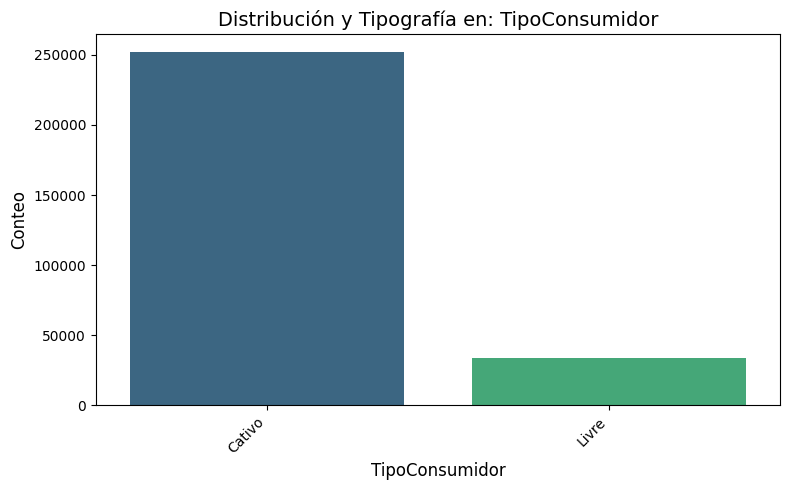

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


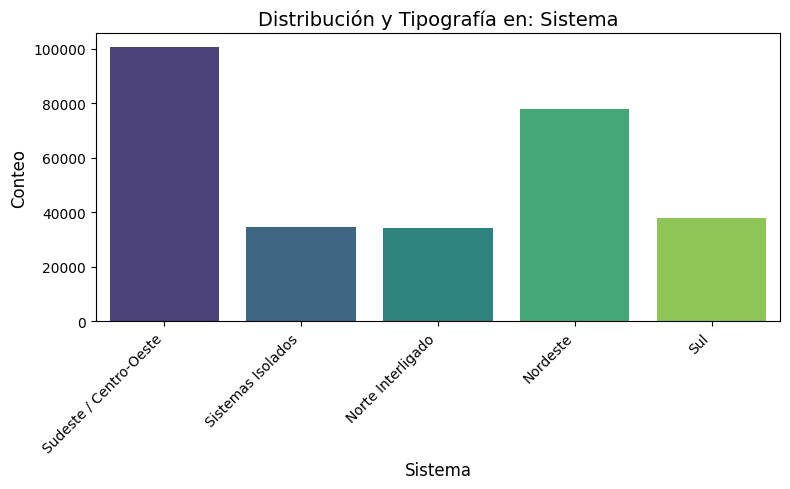

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


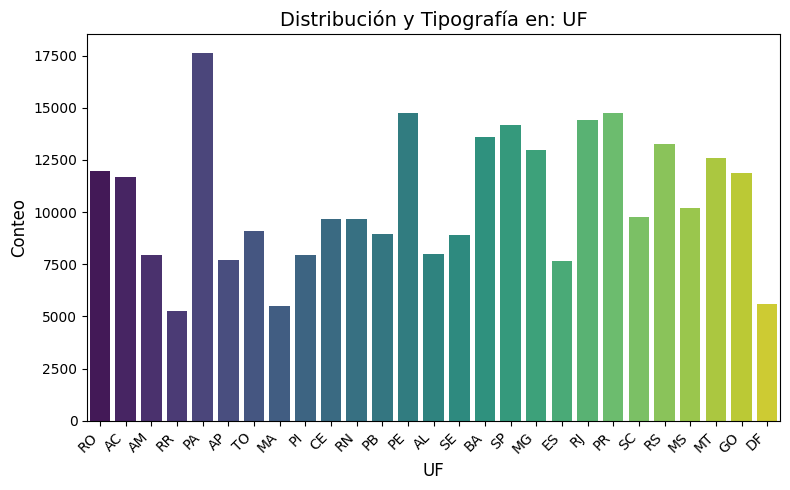

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


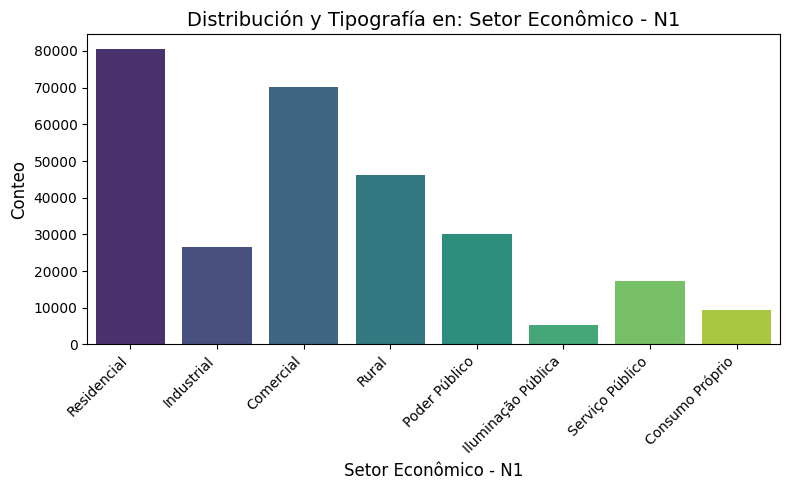

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


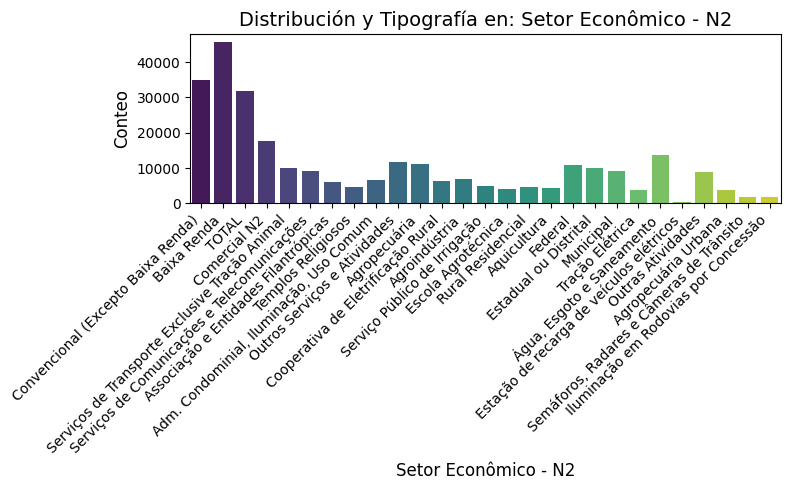

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


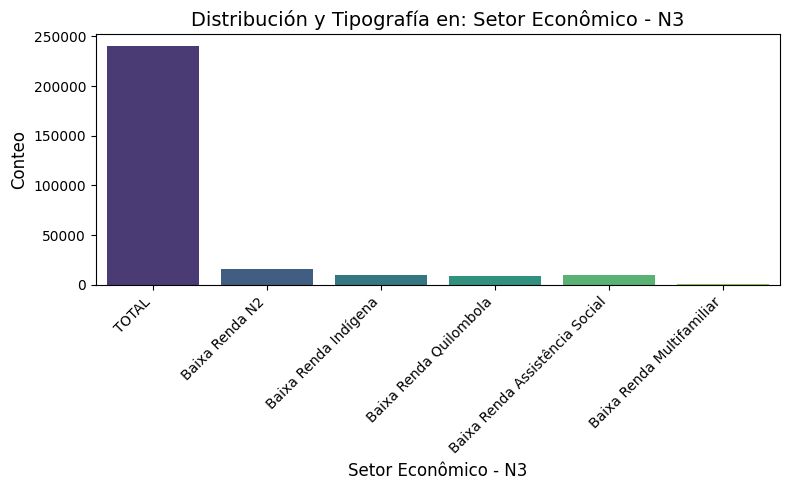

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


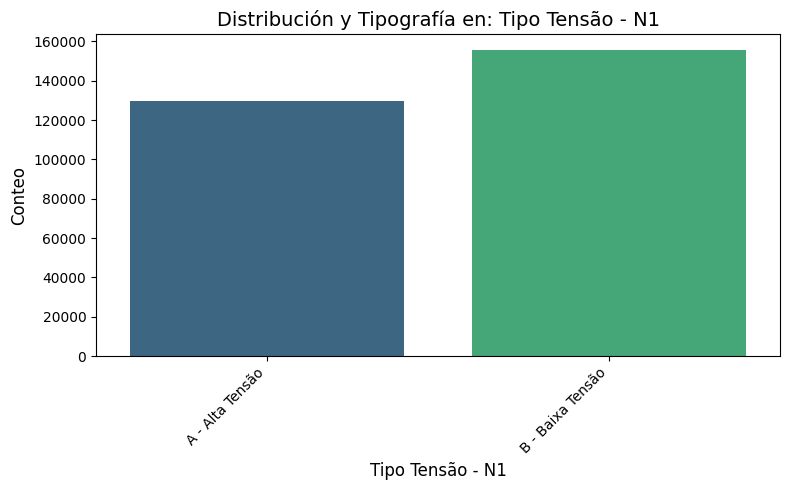

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


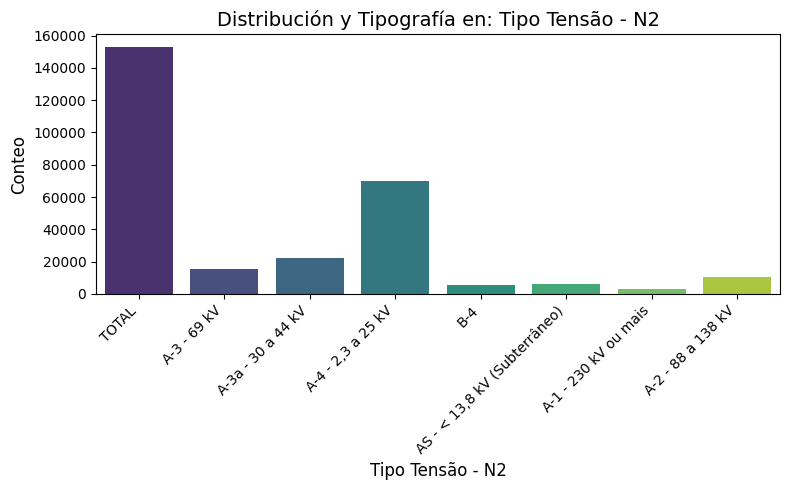

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


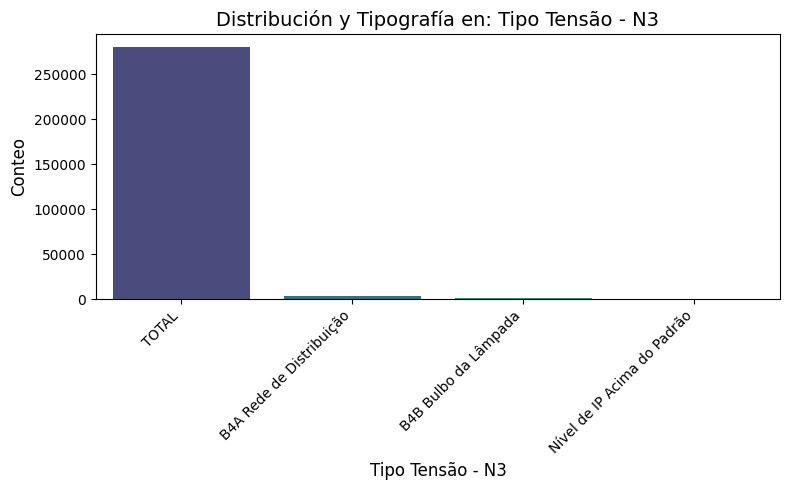

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


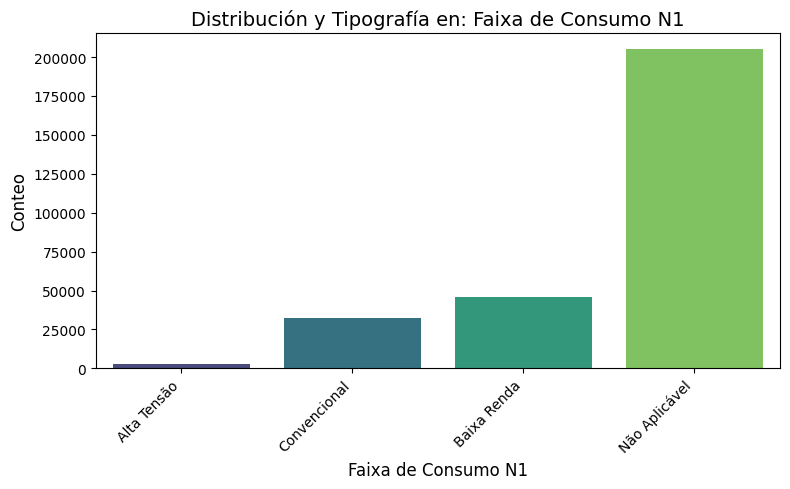

C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col_cat, data=self.df_eb, ax=ax, palette='viridis')
C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\930321747.py:56: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


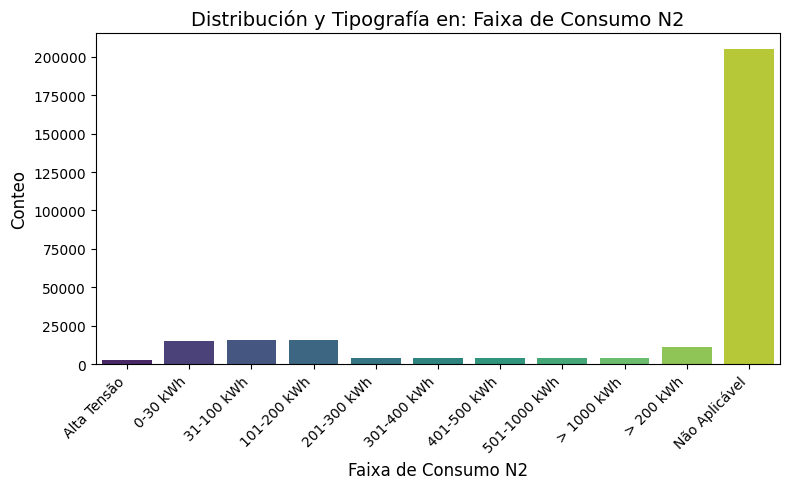

In [9]:
clean_01.verificar_errores_tipograficos()

### **3. Verificar datos faltantes**

In [10]:
clean_01.verificar_nulos()

🛑 Se encontraron datos faltantes en las siguientes columnas: 
              Cantidad Nulos  Porcentaje Nulos
Consumo                 9700               3.4
Consumidores            3988               1.4


### **4. Rellenar datos faltantes con 0**
**Objetivo:** el hecho que no tengan datos puede significar por ejemplo que en la Columna Consumo no hubo consumo electrico o en la columna Consumidores se puede asumir que no hubo consumidores(conteo 0). Puede presumirse de que estos datos pueden ser validos teniendo encuenta que Brasil puede tener areas gegograficas sin consumo electrico como la zona del amazonas. O sea presumimos que en realidad el Consumo es 0 en ciertas zonas por lo tanto consumidores tambien.

In [11]:
clean_01.rellenar_nulos_cero()

In [12]:
# Mostrar informacion del dataframe luego de imputar las celdas con 0
clean_01.data_info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 285499 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  285499 non-null  datetime64[ns]
 1   TipoConsumidor        285499 non-null  object        
 2   Sistema               285499 non-null  object        
 3   UF                    285499 non-null  object        
 4   Setor Econômico - N1  285499 non-null  object        
 5   Setor Econômico - N2  285499 non-null  object        
 6   Setor Econômico - N3  285499 non-null  object        
 7   Tipo Tensão - N1      285499 non-null  object        
 8   Tipo Tensão - N2      285499 non-null  object        
 9   Tipo Tensão - N3      285499 non-null  object        
 10  Faixa de Consumo N1   285499 non-null  object        
 11  Faixa de Consumo N2   285499 non-null  object        
 12  Consumidores          285499 non-null  float64       
 13 

### **5. Verificar si hay valores negativos en la columna Consumo y Consumidores.**

In [13]:
clean_01.verificar_valores_negativos()

--- Verificación de Valores Negativos ---
❌ ¡ALERTA! Se encontraron 59 valores negativos en la columna 'Consumidores'.
❌ ¡ALERTA! Se encontraron 635 valores negativos en la columna 'Consumo'.


### **6. Proceder a eliminar los datos que tienen valores negativos en las columnas Consumo y Consumidores.**

In [14]:
clean_01.eliminar_negativos()

--- Eliminación de Valores Negativos ---
✅ Se eliminaron 675 filas con valores negativos.
El DataFrame ahora tiene 284824 filas.


In [15]:
clean_01.data_info()

<class 'pandas.core.frame.DataFrame'>
Index: 284824 entries, 0 to 285498
Data columns (total 14 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  284824 non-null  datetime64[ns]
 1   TipoConsumidor        284824 non-null  object        
 2   Sistema               284824 non-null  object        
 3   UF                    284824 non-null  object        
 4   Setor Econômico - N1  284824 non-null  object        
 5   Setor Econômico - N2  284824 non-null  object        
 6   Setor Econômico - N3  284824 non-null  object        
 7   Tipo Tensão - N1      284824 non-null  object        
 8   Tipo Tensão - N2      284824 non-null  object        
 9   Tipo Tensão - N3      284824 non-null  object        
 10  Faixa de Consumo N1   284824 non-null  object        
 11  Faixa de Consumo N2   284824 non-null  object        
 12  Consumidores          284824 non-null  float64       
 13  Cons

### **7. Verificar Outliers (valores atipicos)**

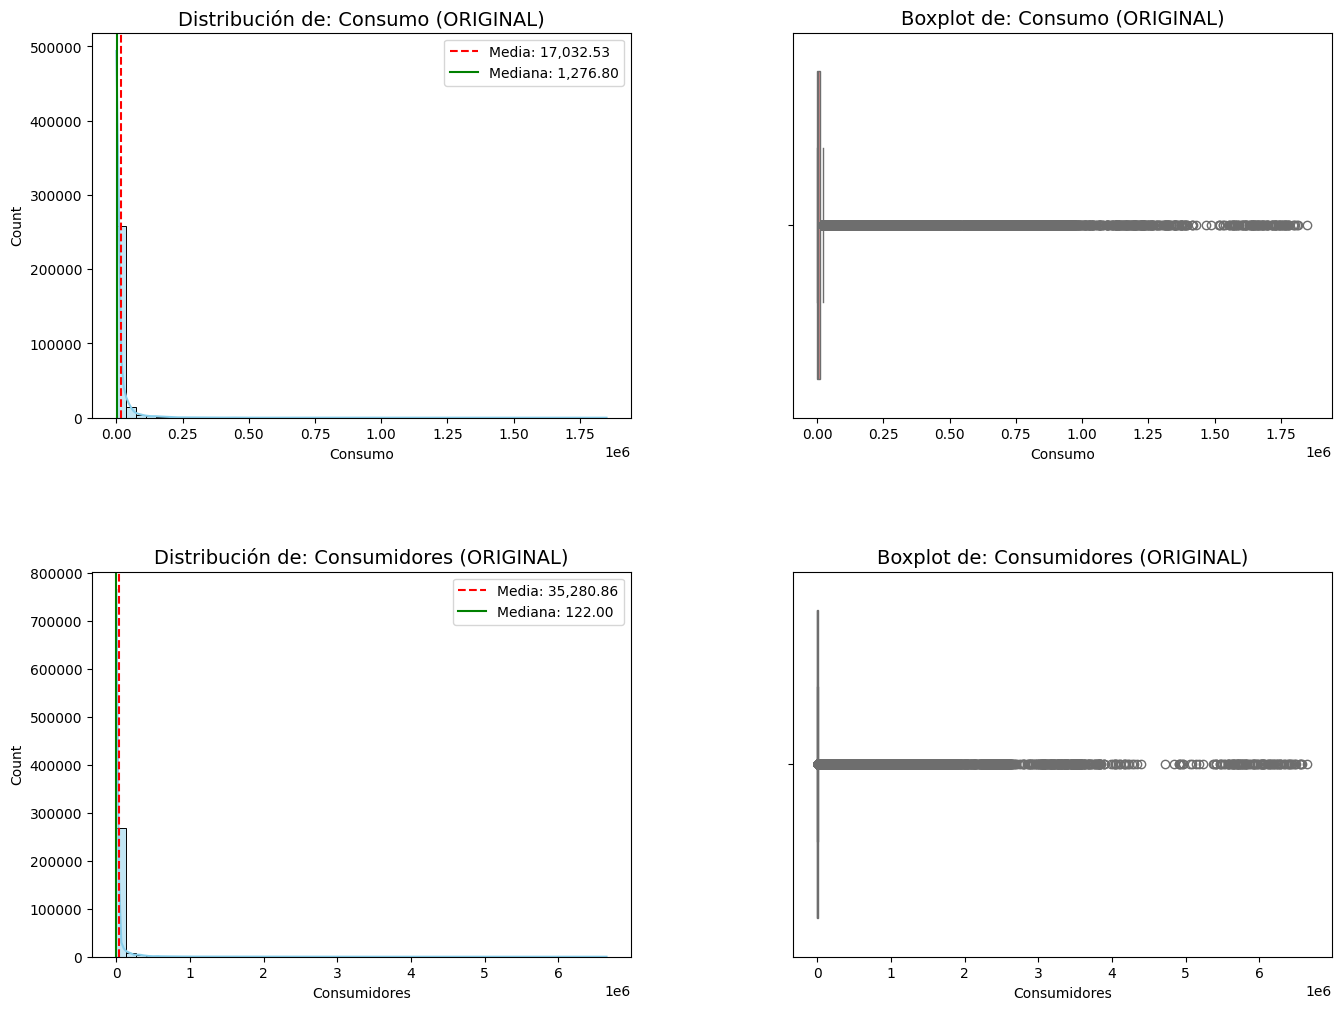

In [16]:
clean_01.verificar_outlier(log_scale=False)

### **8. Aplicar capping a los datos considerados Outliers**

In [17]:
clean_01.capping_outliers()

Iniciando deteccion y tratamiento de valores atipicos
-> En 'Consumo': 40844 valores atípicos limitados (Capping) al valor de 22385.00.
-> En 'Consumidores': 57035 valores atípicos limitados (Capping) al valor de 7513.00.


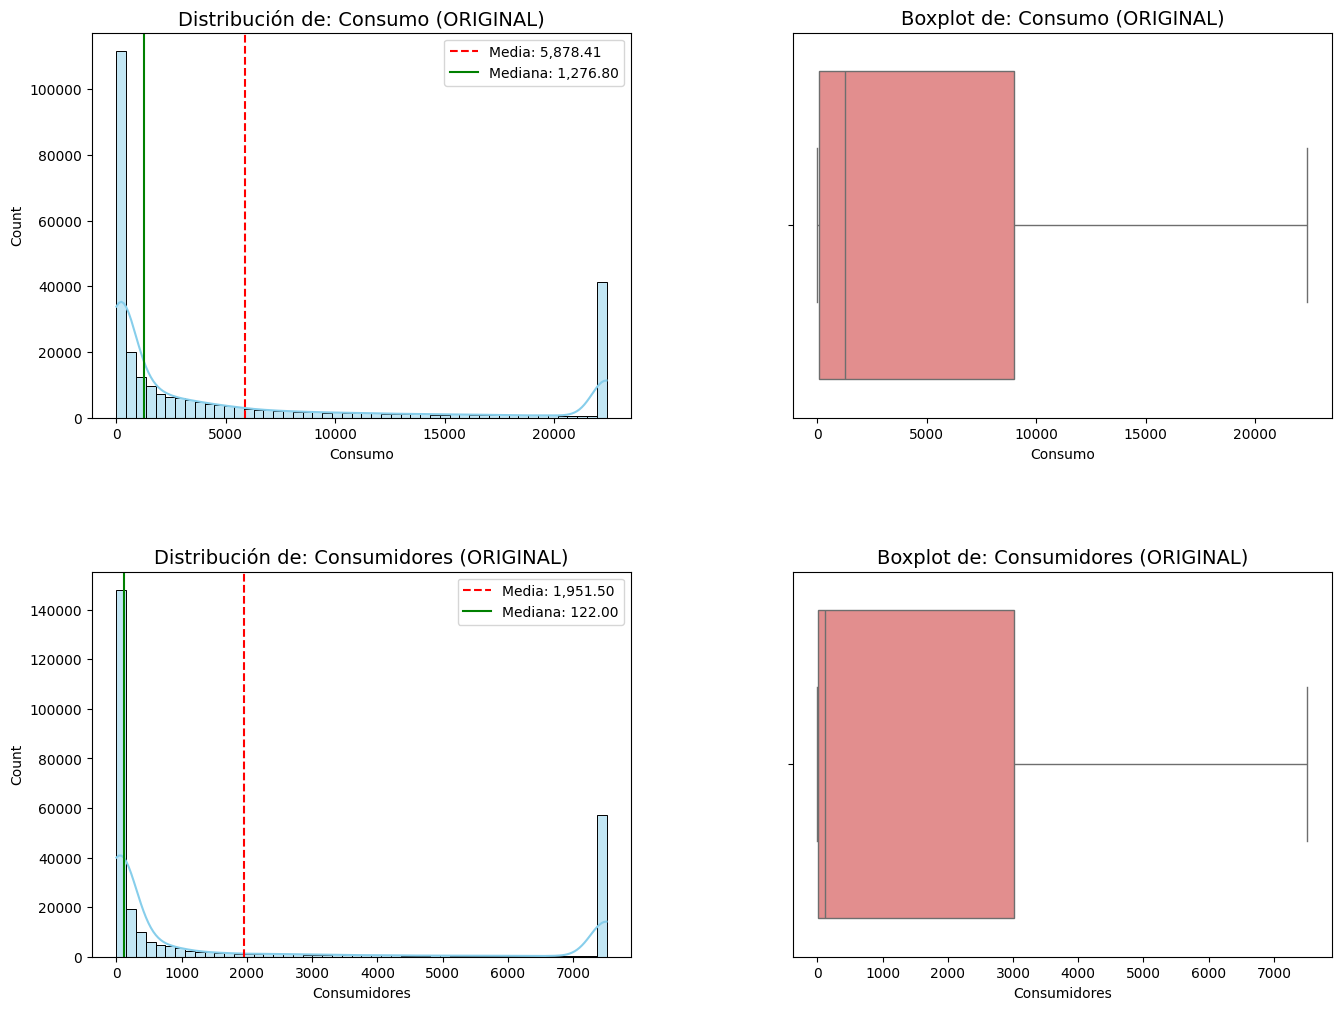

In [18]:
clean_01.verificar_outlier(log_scale=False)

In [19]:
clean_01.confirmar_capping()

22385.0


### **9.Transformacion logaritmica de datos (Consumo, Consumidores)**

In [20]:
clean_01.transformar_logaritmica()  # crea dos columnas nuevas (Consumo_Log, Consumidores_Log)

Aplicando Transformación Logarítmica a Consumo y Consumidores...
✅ Transformación completada. Nuevas columnas listas para el análisis.


In [21]:
clean_01.data_info()


<class 'pandas.core.frame.DataFrame'>
Index: 284824 entries, 0 to 285498
Data columns (total 16 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Data                  284824 non-null  datetime64[ns]
 1   TipoConsumidor        284824 non-null  object        
 2   Sistema               284824 non-null  object        
 3   UF                    284824 non-null  object        
 4   Setor Econômico - N1  284824 non-null  object        
 5   Setor Econômico - N2  284824 non-null  object        
 6   Setor Econômico - N3  284824 non-null  object        
 7   Tipo Tensão - N1      284824 non-null  object        
 8   Tipo Tensão - N2      284824 non-null  object        
 9   Tipo Tensão - N3      284824 non-null  object        
 10  Faixa de Consumo N1   284824 non-null  object        
 11  Faixa de Consumo N2   284824 non-null  object        
 12  Consumidores          284824 non-null  float64       
 13  Cons

### **10. Verificar Outliers con los nuevos datos logaritmicos.**

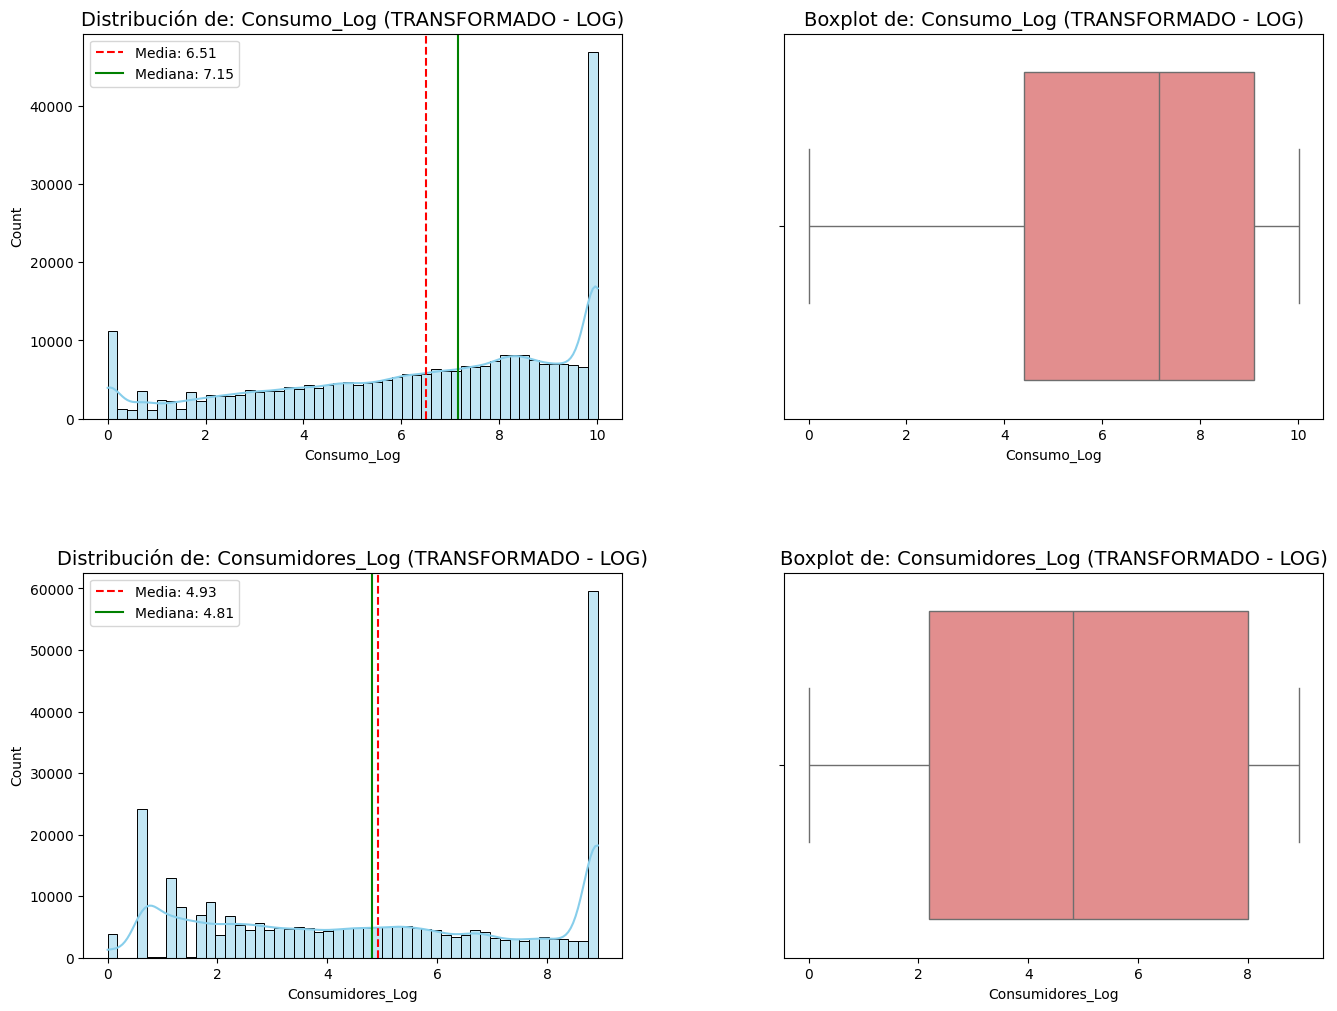

In [22]:
clean_01.verificar_outlier(log_scale=True)

+ ### **Clases y metodos para realizar analisis exploratorio (EDA)**

In [23]:
import calendar

class EnergyAnalyzer:
    def __init__(self, df_cleaned: pd.DataFrame):
        """Inicializa el analizador con el DataFrame ya limpio y transformado."""
        self.df = df_cleaned
        print("Analizador de Energía inicializado con DataFrame listo.")
        
    # -------------------------------------------------------------------------
    # 1. Análisis de Temporalidad (Tendencias y Estacionalidad): grafica el consumo total mes a mes a lo largo de los años
    # -------------------------------------------------------------------------
    def analizar_temporalidad(self):
        """Calcula y grafica la tendencia mensual del consumo logarítmico total."""
        print("\n--- 1. Análisis de Tendencia Mensual ---")
        
        # Agrupar por mes/año y sumar el consumo logarítmico.
        # Esto mitiga el impacto de los outliers y muestra la tendencia real.
        '''1. set.index('Data'): convierte la columna de fechas y horas (Data) del dataframe self.df en el indice del dataframe, 
              para poder usar la funcionalidad de remuestreo (resempling) de Pandas, es un requisito que la columna de fechas sea el indice.
           2. resample('M'): agrupa el dataframe por periodos de tiempo
              Argumento 'M': significa "Month End Frequency (Frecuencia de fin de mes), que crea un grupo de filas para cada mes presente en los datos.)
           3. ['Consumo_Log']: selecciona la columna Consumo_Log para realizar la agregacion.
           4. sum(): aplica la suma a todos los valores de la columna Consumo_Log dentro de cada grupo mensual.
           5. reset_index(): convierte el indice de fecha de nuevo en una columna regular del dataframe, para graficar la serie de tiempo con Seaborn
           '''
        df_tendencia = self.df.set_index('Data').resample('ME')['Consumo_Log'].sum().reset_index() # devuelve un dataframe (df_tendencia) que contiene una fila
                                                                                                  # por cada mes/ano y el consumo total agregado para ese periodo
        
        plt.figure(figsize=(12, 6))
        sns.lineplot(x='Data', y='Consumo_Log', data=df_tendencia, linewidth=2, color='darkorange')
        plt.title('Tendencia del Consumo Total (Escala Logarítmica) Mensual', fontsize=16)
        plt.xlabel('Fecha', fontsize=12)
        plt.ylabel('Consumo Total (Log)', fontsize=12)
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

    # -------------------------------------------------------------------------
    # 2. preparar_datos_estacionalidad: prepara la segmentacion delos diferentes grupos determinados (ej: 'Residencial'),
    # para ver como el consumo de grupos determinados , cambia mes a mes a lo largo de los años.
    # -------------------------------------------------------------------------
    def _preparar_datos_estacionalidad(self, df, filtro_columna, filtro_valor):
        """Función auxiliar para preparar los datos de estacionalidad.
           Patrones de estacionalidad: se refiere a las fluctuaciones en una serie de tiempo que
           ocurren con regularidad y se repiten en periodos fijos de tiempo, clave para entender como
           el consumo varia segun el momento del ano.
        """

        # segmentar los datos por categoria espesifica antes de realizar el analisis de estacionalidad.
        # Objetivo: seleccionar un subconjunto de filas del dataframe basandose en una condicion espesifica,
        # y luego crear una copia indipendiente de esos datos.

        # Devuelve una Serie booleanda (una columna de True o False)
        df_estacionalidad = df[df[filtro_columna] == filtro_valor].copy()
        
        if df_estacionalidad.empty:
            return None, "No hay datos", 0

        # Aislar y almacenar el año de la columna fechas en una nueva columna.
        # .dt es un metodo de pandas (datetime) que permite acceder a componentes espesificos de la fecha   
        df_estacionalidad['Año'] = df_estacionalidad['Data'].dt.year
        df_estacionalidad['Mes_Numero'] = df_estacionalidad['Data'].dt.month
        
        # agrupar el consumo logaritmico por cada combinacion unica de Año y mes, y luego sumando esos valores.
        # .reset_index() separa el index de año y mes y lo almacena en las nuevas columnas Año, Mes_Numero
        df_agrupado = df_estacionalidad.groupby(['Año', 'Mes_Numero'])['Consumo_Log'].sum().reset_index()

        # Convertir los numeros del mes (1,2,3...) en sus nombres abreviados (Ene, Feb, Mar.....)
        df_agrupado['Mes_Nombre'] = df_agrupado['Mes_Numero'].apply(lambda x: calendar.month_abbr[x])
        
        # Devuelve el df_agrupado que contiene (Año, Mes, Consumo_log), la etiqueta de filtrado filtro_valor y calcula y devuelve 
        # la suma total del consumo logaritmico para el segmento que se quiere analizar.
        return df_agrupado, filtro_valor, df_estacionalidad['Consumo_Log'].sum()

    # -------------------------------------------------------------------------
    # 3. Comparación de Estacionalidad: Alta vs. Baja Tensión
    # -------------------------------------------------------------------------
    def comparar_estacionalidad_tension(self, columna_tension='Tipo Tensão - N1'):
        """
        Compara la estacionalidad del consumo (Log) de Alta Tensión vs. Baja Tensión.
        """
        print("\n--- Comparación de Estacionalidad: Alta vs. Baja Tensión ---")
        
        tensiones = ['A - Alta Tensão', 'B - Baixa Tensão']
        
        fig, axes = plt.subplots(
            nrows=1, 
            ncols=2, 
            figsize=(18, 7) # Figura ancha para 2 gráficos lado a lado
        )
        plt.subplots_adjust(wspace=0.3)

        for i, tension in enumerate(tensiones):
            
            # Usar la función auxiliar para preparar los datos de cada segmento
            df_agrupado, valor, consumo_total = self._preparar_datos_estacionalidad(
                self.df, columna_tension, tension
            )

            if df_agrupado is None:
                axes[i].set_title(f"Sin datos para {tension}", fontsize=16)
                continue
                
            # Graficar
            sns.lineplot(
                data=df_agrupado,
                x='Mes_Numero',
                y='Consumo_Log',
                hue='Año',
                palette='tab10',
                linewidth=2,
                ax=axes[i]
            )
            
            # Configuración de Ejes y Títulos
            # Mostrar las etiquetas en el eje x de los nombres abreviados de los meses en el orden correcto.
            axes[i].set_xticks(
                df_agrupado['Mes_Numero'].unique(), 
                df_agrupado.sort_values('Mes_Numero')['Mes_Nombre'].unique() # el metodo unique elimina cualquier duplicado en una Serie de pandas.
            )
            axes[i].set_title(f'Estacionalidad Mensual: {tension}', fontsize=16)
            axes[i].set_xlabel('Mes', fontsize=12)
            axes[i].set_ylabel('Consumo Total Acumulado (Log)', fontsize=12)
            axes[i].legend(title='Año', loc='upper right')
            axes[i].grid(True, linestyle='--', alpha=0.6)

        plt.suptitle('Análisis Comparativo de Estacionalidad (Consumo Log)', fontsize=20, y=1.02)
        plt.show()



    # -------------------------------------------------------------------------
    # 3. Análisis Geográfico (Top UFs/Estados por Consumo)
    #    Analisis consumo por cada Estado o Departamento geografico.
    # -------------------------------------------------------------------------
    def analizar_geografia(self, top_n=10):
        """Identifica los estados (UF) con mayor consumo total."""
        print(f"\n--- 2. Análisis Geográfico (Top {top_n} UFs por Consumo Absoluto) ---")
        
        # Usamos Consumo original para reportar el valor absoluto de negocio
        df_geo = self.df.groupby('UF')['Consumo'].sum().sort_values(ascending=False)
        
        num_ufs = len(df_geo)
        plt.figure(figsize=(num_ufs * 0.5, 6))
        
        # Gráfico de barras con anotaciones para mejor lectura
        ax = df_geo.plot(kind='bar', color=sns.color_palette("viridis"))
        
        plt.title(f'Top {top_n} UFs (Estados) por Consumo Total Acumulado', fontsize=16)
        plt.xlabel('UF (Estado)', fontsize=12)
        plt.ylabel('Consumo Total (Millones)', fontsize=12)
        plt.xticks(rotation=45, ha='right')
        plt.ticklabel_format(style='plain', axis='y') # Evita notación científica en Y
        plt.grid(axis='y', linestyle='--', alpha=0.6)
        plt.show()

    # -------------------------------------------------------------------------
    # 4. Análisis del Mix de Clientes (Consumo por Sector N1)
    #    Analisis consumo por tipo de clientes (Residencial, Industrial, etc)
    # -------------------------------------------------------------------------
    def analizar_mix_clientes(self):
        """
        Analiza qué sector (N1) domina el mercado en términos de Consumo Total.
        """
        print("\n--- 4. Análisis del Mix de Clientes por Sector Económico (N1) ---")
        
        # 1. Agregación de datos por Consumo Total
        df_mix = self.df.groupby('Setor Econômico - N1')['Consumo'].sum().reset_index()

        # Ordenar por el mayor Consumo para la visualización
        df_mix = df_mix.sort_values(by='Consumo', ascending=False)
        
        # 2. Visualización
        plt.figure(figsize=(10, 6))
        
        sns.barplot(
            x='Consumo', 
            y='Setor Econômico - N1', 
            data=df_mix, 
            palette=sns.color_palette("plasma", len(df_mix))
        )
        
        plt.title('Dominancia de Consumo Total por Sector Económico (N1)', fontsize=16)
        plt.xlabel('Consumo Total Acumulado (Escala Original)', fontsize=12)
        plt.ylabel('Sector Económico (N1)', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.ticklabel_format(style='plain', axis='x') # Desactiva la notacion cientifica en el eje x del grafico.
        plt.show()
        
        # 3. Reporte del Dominio
        # .iloc[0] accede a la fila de la posicion 0 del dataframe que es el que mayor consumo tiene, teniendo en cuenta que el 
        # dataframe esta ordenado de mayor a menor.
        dominante = df_mix.iloc[0]['Setor Econômico - N1'] # Extrae el cliente con mayor consumo del dataframe df_mix.
        print(f"\n💡 El sector dominante en el mercado de consumo es: {dominante}")
        print("A continuación, debemos adaptar el análisis temporal exclusivamente para este sector.")

    # -------------------------------------------------------------------------
    # 5. Análisis de Proporción Consumo vs. Consumidores (Tensión)
    # -------------------------------------------------------------------------
    def analizar_proporcion_tension(self, columna_tension='Tipo Tensão - N1'): # <-- Columna por defecto
        """
        ¿El mayor consumo proviene de un pequeño numero de clientes de alta tension,
        o esta distribuido equitativamente entre los clientes?.
        Utiliza la columna 'Tipo Tensão - N1' por defecto.
        """
        print(f"\n--- 5. Análisis de Concentración del Mercado por Tensión: {columna_tension} ---")

        if columna_tension not in self.df.columns:
            # Esta validación sigue siendo útil si se llama con otra columna
            print(f"❌ Error: La columna '{columna_tension}' no se encuentra en el DataFrame.")
            return

        # 1. Agrupar por la columna de tensión y calcular los totales
        # el metodo .agg (Agregacion multiple), permite agregar multiples funciones de agregacion (sum) 
        # a columnas espesificas dentro de cada grupo de tension.
        df_tension = self.df.groupby(columna_tension).agg(
            Consumo_Total=('Consumo', 'sum'),  # suma la columna Consumo de cada grupo y guarda el resultado en la nueva columna Consumo_Total
            Consumidores_Total=('Consumidores', 'sum') # suma la columna Consumidores de cada grupo y guarda el resultado en la nueva columna Consumidores_Total
        ).reset_index()

        # 2. Calcular la proporción (%) de cada métrica sobre el total general
        consumo_total_gral = df_tension['Consumo_Total'].sum()
        consumidores_total_gral = df_tension['Consumidores_Total'].sum()

        df_tension['Consumo_Prop'] = (df_tension['Consumo_Total'] / consumo_total_gral) * 100
        df_tension['Consumidores_Prop'] = (df_tension['Consumidores_Total'] / consumidores_total_gral) * 100

        # 3. Preparar los datos para la visualización
        # la funcion melt se utiliza para despivotar un DataFrame, convertir las columnas en filas.
        df_plot = df_tension.melt(
            id_vars=[columna_tension], # define las columnas que no se van a despivotar, permanecen columnas.
            value_vars=['Consumo_Prop', 'Consumidores_Prop'],  # columnas que se van a despivotar, sus nombres se convertiran en valores en una nueva columna, y sus valores se moveran a una nueva columna.
            var_name='Métrica', # nombre de la nueva columna que contendran los nombres de (Conumo_Prop, Consumidores_prop)
            value_name='Proporción (%)' # nombre de la nueva columna que contendra los valores numericos de las columnas despivotadas.
        )
        
        # 4. Graficar la concentración
        plt.figure(figsize=(10, 6))
        
        sns.barplot(
            x='Proporción (%)', 
            y=columna_tension, 
            hue='Métrica', 
            data=df_plot,
            palette={'Consumo_Prop': 'darkred', 'Consumidores_Prop': 'darkblue'}
        )
        
        plt.title(f'Proporción de Consumo vs. Consumidores por {columna_tension}', fontsize=16)
        plt.xlabel('Proporción del Total del Mercado (%)', fontsize=12)
        plt.ylabel(columna_tension, fontsize=12)
        plt.legend(title='Métrica')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.show()
        
    # -------------------------------------------------------------------------
    # 6. Análisis Sectorial (Promedio de Consumo por Sector)
    # -------------------------------------------------------------------------
    def analizar_sector_consumo(self):
        """Identifica los sectores económicos más importantes por consumo logarítmico promedio."""
        print("\n--- 3. Análisis Sectorial por Consumo Promedio (Log) ---")
        
        # Usar Consumo_Log promedio para una distribución más justa del peso (menos sensible a outliers)
        df_sector = self.df.groupby('Setor Econômico - N1')['Consumo_Log'].mean().sort_values(ascending=False)
        
        plt.figure(figsize=(12, 8))
        ax = df_sector.plot(kind='barh', color='teal') # Gráfico horizontal para mejor lectura
        
        plt.title('Ranking de Consumo Promedio (Log) por Sector Económico', fontsize=16)
        plt.xlabel('Consumo Promedio (Log)', fontsize=12)
        plt.ylabel('Sector Económico', fontsize=12)
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.show()

    # -------------------------------------------------------------------------
    # 7. Tendencia Anual del Consumo Industrial por Región (UF)
    # -------------------------------------------------------------------------
    def analizar_tendencia_industrial_regional(self, setor_n1='Industrial'):
        """
        Genera un gráfico que muestra la variación del Consumo Total (Log) 
        del sector industrial, comparando las regiones (UF) a lo largo de los años.
        
        :param setor_n1: Nombre exacto del sector industrial en N1 (por defecto 'INDUSTRIA').
        """
        
        print(f"\n--- Tendencia Anual del Consumo Total de {setor_n1} por Región ---")

        # 1. Validación y Filtrado Inicial por Sector N1 (Industria)
        df_industrial = self.df.copy()

        if setor_n1 not in df_industrial['Setor Econômico - N1'].unique():
             print(f"❌ Error: El sector N1 '{setor_n1}' no se encontró. Revise el nombre exacto en su DataFrame.")
             return
        
        df_industrial = df_industrial[
            df_industrial['Setor Econômico - N1'] == setor_n1
        ]
        
        if df_industrial.empty:
            print(f"⚠️ No se encontraron datos para el sector: {setor_n1}.")
            return
            
        # 2. Preparación temporal y agrupación
        df_industrial['Año'] = df_industrial['Data'].dt.year
        
        # Agrupación clave: por Año y UF, sumando el Consumo_Log
        df_agrupado = df_industrial.groupby(['Año', 'UF'])['Consumo_Log'].sum().reset_index()
        
        # 3. Graficar con FacetGrid (simulando relplot para control)
        plt.figure(figsize=(14, 8))
        
        # Usamos lineplot para conectar los años y scatterplot para los puntos
        sns.lineplot(
            data=df_agrupado,
            x='UF', 
            y='Consumo_Log', 
            hue='Año', 
            palette='viridis', # Usamos una paleta con variación de color por Año
            marker='o',        # Añadimos marcadores para ver los puntos de dato
            linewidth=2
        )
        
        # 4. Configuración de Ejes y Títulos
        plt.title(f'Tendencia del Consumo Industrial Total (Log) por UF y Año', fontsize=18)
        plt.xlabel('Región (UF)', fontsize=14)
        plt.ylabel('Consumo Total Acumulado (Log)', fontsize=14)
        
        # Posicionamos la leyenda
        plt.legend(title='Año', bbox_to_anchor=(1.0, 1), loc='upper left')
        
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 8. Uso de Tensión (Alta/Baja) por Sector Económico
    # -------------------------------------------------------------------------
    def analizar_tension_por_sector(self, columna_sector='Setor Econômico - N1', columna_tension='Tipo Tensão - N1'):
        """
        Grafica el número total de consumidores para cada Sector Económico (N1), 
        diferenciando por el tipo de Tensión (N1).
        """
        
        print(f"\n--- 10. Consumidores por Sector Económico vs. Tipo de Tensión ---")

        # 1. Agrupación de datos: Consumidores por Sector y Tensión
        df_agrupado = self.df.groupby([columna_sector, columna_tension])['Consumidores'].sum().reset_index()
        
        # 2. Crea una variable orden_sectores para ordenar las barras por Consumidores totales
        orden_sectores = df_agrupado.groupby(columna_sector)['Consumidores'].sum().sort_values(ascending=False).index
        
        # 3. Graficar
        plt.figure(figsize=(14, 8))
        
        sns.barplot(
            data=df_agrupado,
            x='Consumidores', 
            y=columna_sector, 
            hue=columna_tension, 
            order=orden_sectores,
            palette={'A - Alta Tensão': 'darkred', 'B - Baixa Tensão': 'darkblue'} # Paleta clara para distinción
        )

        # 4. Configuración de Ejes y Títulos
        plt.title(f'Distribución de Consumidores por Sector Económico y Tipo de Tensión', fontsize=18)
        plt.xlabel('Número Total de Consumidores', fontsize=14)
        plt.ylabel(columna_sector, fontsize=14)
        
        plt.ticklabel_format(style='plain', axis='x') # Evita notación científica en el Eje X
        
        plt.legend(title=columna_tension, loc='lower right')
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 9. Proporción de Clientes por Rango de Consumo (Faixa de Consumo)
    # -------------------------------------------------------------------------
    def analizar_segmentacion_clientes(self, columna_rango='Faixa de Consumo'):
        """
        Grafica la proporción del número total de consumidores que cae en cada
        rango de consumo (Faixa de Consumo).
        """
        
        print(f"\n--- 11. Proporción de Consumidores por Rango de Consumo ({columna_rango}) ---")

        # 1. Agrupar el número total de consumidores por rango
        df_segmento = self.df.groupby(columna_rango)['Consumidores'].sum().reset_index()

        # 2. Calcular el porcentaje de consumidores en cada rango
        total_consumidores = df_segmento['Consumidores'].sum()
        df_segmento['Proporcion (%)'] = (df_segmento['Consumidores'] / total_consumidores) * 100
        
        # 3. Ordenar los rangos si es posible (asumiendo que son categóricos y ordenados)
        # Esto requiere que los rangos estén en un orden lógico, si no, se ordenará alfabéticamente.
        # En Seaborn, un gráfico de pastel o barras ordenadas funciona bien.
        df_segmento = df_segmento.sort_values(by='Proporcion (%)', ascending=False)
        
        # 4. Graficar (Gráfico de barras para mejor lectura de valores bajos)
        plt.figure(figsize=(10, 8))
        ax = sns.barplot(
            data=df_segmento,
            x='Proporcion (%)', 
            y=columna_rango, 
            palette='Reds_d' # Paleta que destaca los rangos superiores (con mayor proporción)
        )
        
        plt.title('Distribución Porcentual de Consumidores por Rango de Consumo', fontsize=16)
        plt.xlabel('Proporción del Total de Consumidores (%)', fontsize=12)
        plt.ylabel('Rango de Consumo', fontsize=12)
        
        # Opcional: Anotar los valores para los rangos más pequeños
        # Añadir etiquetas numericas directamente sobre las barras de un grafico.
        # ax.patches: es una lista que contiene todos los objetos graficos individuales (rectangulos o parches) que componen las barras del grafico
        # el bucle for recorre cada barra (p) del grafico.
        for p in ax.patches:   
            width = p.get_width()  # obtener la logitud de la barra
            plt.text(width + 1, p.get_y() + p.get_height()/2. + 0.1,  # configurar el formato del texto
                     '{:1.1f}%'.format(width),
                     ha="left", fontsize=10)
        
        plt.grid(axis='x', linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

    # -------------------------------------------------------------------------
    # 10. Dinámica de Consumidores: Migración entre Rangos por Año
    # -------------------------------------------------------------------------
    def analizar_dinamica_crecimiento(self, columna_rango='Faixa de Consumo N2'):
        """
        Analiza la migración de consumidores entre rangos a lo largo de los años.
        El crecimiento general puede deberse a: 
        1) Clientes en rangos bajos se mueven a medios. 
        2) Clientes grandes consumen más.
        """
        
        print(f"\n--- 12. Dinámica de Crecimiento: Evolución de Consumidores por Rango ({columna_rango}) ---")

        # 1. Preparación temporal y agrupación
        df_dinamica = self.df.copy()
        df_dinamica['Año'] = df_dinamica['Data'].dt.year
        
        # Agrupación clave: por Año y Rango, sumando el número de Consumidores
        df_agrupado = df_dinamica.groupby(['Año', columna_rango])['Consumidores'].sum().reset_index()
        
        # 2. Graficar: Usaremos un gráfico de líneas para mostrar la evolución por rango
        plt.figure(figsize=(14, 8))
        
        sns.lineplot(
            data=df_agrupado,
            x='Año', 
            y='Consumidores', 
            hue=columna_rango, 
            palette='tab20', # Usar una paleta diversa para distinguir los rangos
            marker='o',
            linewidth=2
        )
        
        # 3. Configuración de Ejes y Títulos
        plt.title(f'Evolución Anual del Número de Consumidores por Rango de Consumo', fontsize=18)
        plt.xlabel('Año', fontsize=14)
        plt.ylabel('Número Total de Consumidores', fontsize=14)
        
        # Asegurar que el eje X muestre los años como números enteros
        plt.xticks(df_agrupado['Año'].unique())
        
        plt.legend(title=columna_rango, bbox_to_anchor=(1.0, 1), loc='upper left')
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.tight_layout()
        plt.show()

In [24]:
df_limpio = clean_01.df_eb
analizador = EnergyAnalyzer(df_limpio)

Analizador de Energía inicializado con DataFrame listo.


### **1. Grafico de temporalidad**
Grafica la variacion de consumo a lo largo de los meses de cada año.

**Objetivo:** entender la dinamica de consumo de energia a lo largo de los años.


--- 1. Análisis de Tendencia Mensual ---


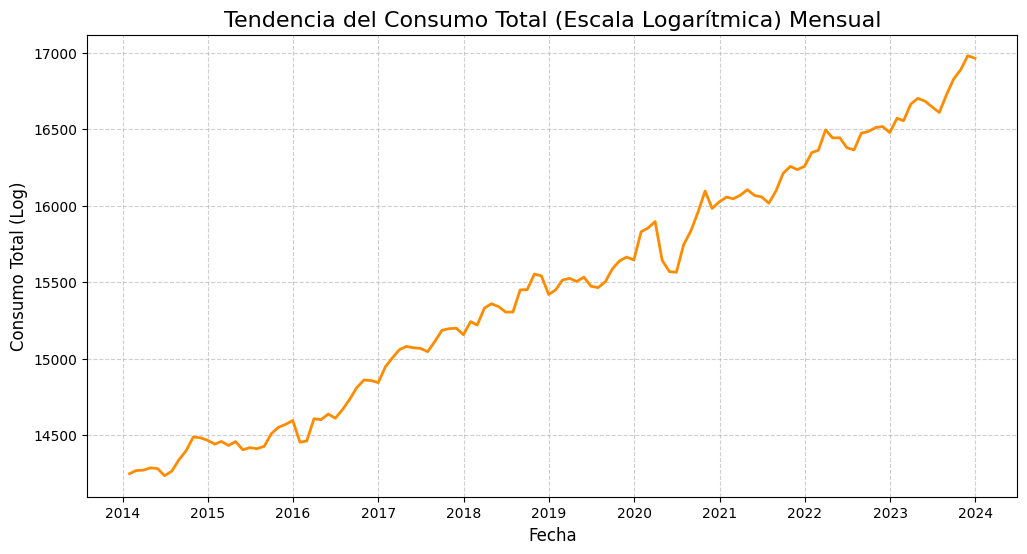

In [25]:

analizador.analizar_temporalidad()


### **Interpretacion grafico temporalidad:**
**1. Tendencia a Largo Plazo: Fuerte Crecimiento**
La caracteristica mas dominate es su fuerte tendencia ascendente y casi lineal desde el 2014 al 2024, indicando un crecimiento sostenido y significativo del consumo total de energia del mercado.
**2. Estacionalidad recurrente.**
La linea muestra fluctuaciones periodicas que se repiten con regularidad cada año.
+ **Patron:** el consumo subre hasta un pico probablemente en verano y luego desciente a un valle antes de reanudar una subida en el siguiente ciclo anual.

Se observa un ralentizado o caida momentanea en la trayectoria ascendente alrededor del periodo 2020-2021. Esto es muy probable que refleje el impacto de la pandemia(COVID-19) donde la actividad economica y los patrones de consumo cambiaron drasticamente debido al confinamiento. Pero luego se recupera la tendencia despues de ese periodo volviendo a la trayectoria del crecimiento previo.

### **2. Grafico de Estacionalidad.**
Muestra la evolucion mensual del Consumo Total Logaritmico para dos segmentos criticos, Alta Tension y Baja Tension, con cada linea representando un año diferente


--- Comparación de Estacionalidad: Alta vs. Baja Tensión ---


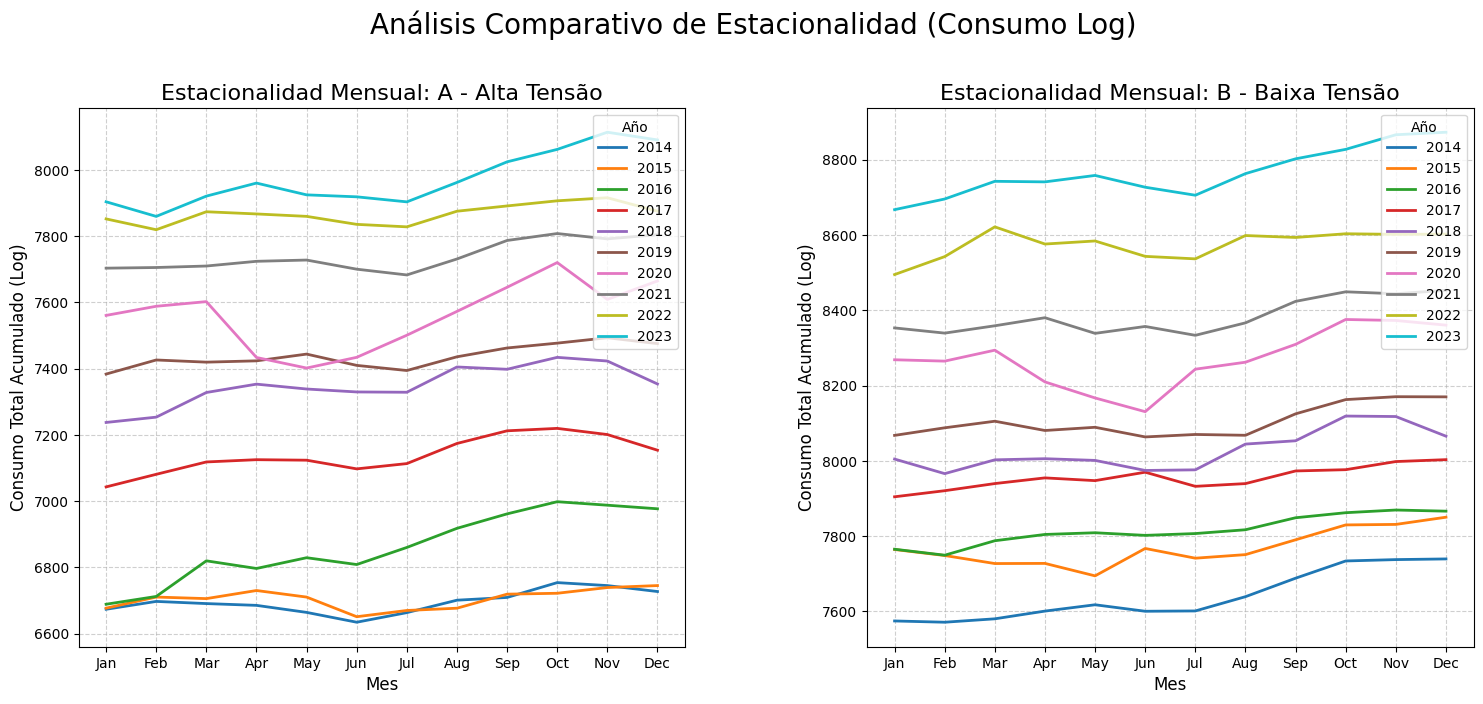

In [26]:
analizador.comparar_estacionalidad_tension()

### **Interpretacion grafico de Estacionalidad.**
**1. Patron de Estacionalidad (Forma de las Curvas).**
El patron es muy similar en ambos graficos, lo que indica que la estacionalidad climatica o de calendario afecta a ambos tipos de clientes.
+ **Pico (meses calidos):** en casi todos los años en ambos graficos el pico de consumo electrico alcanza su punto mas alto en la epoca de verano, desde Agosto a Diciembre, y de Enero a Marzo.
+ **Valle (meses frios):** el consumo tiende a caer en su punto mas bajo alrededor de los meses de Abril hasta Julio.

**2. Tendencia Interanual(Separacion de las lineas).**
Las lineas estan consistentemente separadas, lo que confirma el crecimiento de la tendencia a largo plazo.

**3. Diferencia de concentracion(Alta vs. Baja tension).**
Aunque el patron estacional es similar, las escalas de consumo son diferentes:
+ **Alta Tension(Izquierda):** El consumo total se mueve en un rango aproximado de 7800 a 8200
+ **Baja Tension(Derecha):** El consumo total se mueve en un rango aproximado de 7600 a 8800 con mayor variabilidad.

**Observacion:** el analis de estacionalidad es fundamental para la planificacion de la oferta y la demanda en el sector energetico.
+ **Prevision de Carga:** Permite predecir la demanda futura con mayor precision.
+ **Identificacion de anomalias:** si el consumo de un mes cae fuera de la banda de los patrones historicos de ese mes, es una señal de que algo inusual ocurrio (ej: una ola de calor o de frio extremo)

### **3. Grafico de analisis Geografica.**
Muestra el **Consumo Total Acumulado** (eje Y) para diferentes **Unidades Federativas (UF) o Estados** (eje X)


--- 2. Análisis Geográfico (Top 10 UFs por Consumo Absoluto) ---


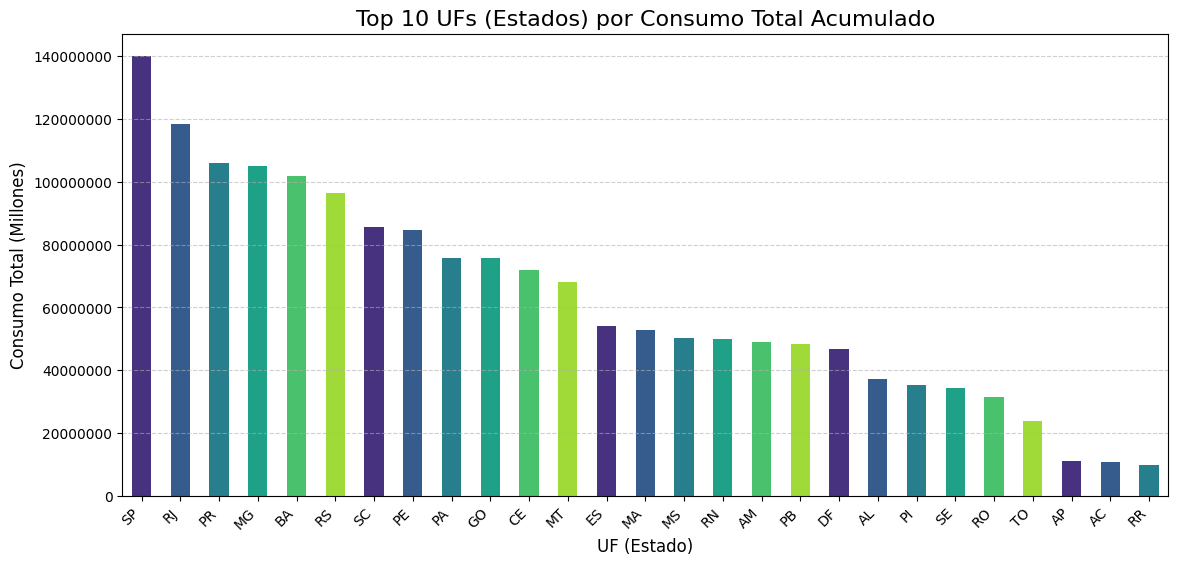

In [27]:
analizador.analizar_geografia()

### **Interpretacion grafico de Analisis Geografico.**
**1.Concentracion Geografica.**
+ **Dominancia clara:** diferencia significativa de consumo entre los estados principales y el resto. Los estados de SP(San Pablo) y RJ(Rio de Janeiro) son los lideres indiscutibles en el consumo de energia electrica.
+ **Potencia vs. Poblacion/Economica:** El patron sugiere que el consumo de energia esta fuertemente correlacionado con los principales centros economicos y/o densamente poblados del pais.

**2.Segmentacion por Grupos.**
+ **Grupo 1 (Dominante):** SP y RJ, con consumo muy superior a 1100 millones.
+ **Grupo 2 (Alto Consumo):** Estados como PR, MG, BA, RS con consumo en el rango de 950 a 1100 millones.
+ **Grupo 3 (Concumo Medio-Alto):** El consumo empieza a distribuirse con mayor uniformidad, aunque en niveles inferiores.
+ **Grupo 4 (Bajo Consumo):** Estados como AP y RR se encuentran en el extremo inferior, con consumos muy bajos en comparacion con el resto.

**3.Conclusion.**
**El analisis revela que la demanda de energia esta altamente centralizada.** Las estrategias de inversion es infraestructura (generacion, transmision y distribucion) deben enfocarse primordialmente en las UFs dominantes (SP, RJ) para manejar la carga.

**Observacion.**

Este grafico es una herramienta esencial para la planificacion de capital y la estrategia comercial a futuro.

**1. Priorizacion de Inversiones:** Identifica donde deben dirigirse la mayoria de las inversiones en infraestructura y mantenimiento de red.

**2. Analisis de desbalance:** Muestra la disparidad regional, lo cual es relevante para el diseño de politicas publicas o tarifas regionales.

**3. Desagregacion de la Tendencia:** Se puede usar como base para desglosar la tendencia de crecimiento general.

### 4. Grafico de "**Dominacia de Consumo Total por Sector Economico (N1)"**.
Muestra como se distribuye la demanda de energia entre las diferentes categorias de clientes.


--- 4. Análisis del Mix de Clientes por Sector Económico (N1) ---


C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\3723423756.py:175: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


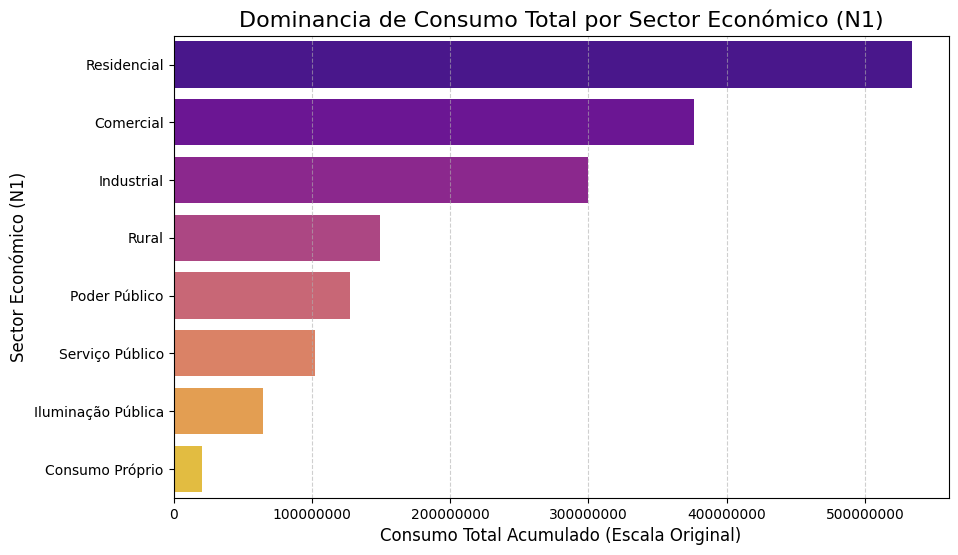


💡 El sector dominante en el mercado de consumo es: Residencial
A continuación, debemos adaptar el análisis temporal exclusivamente para este sector.


In [28]:
analizador.analizar_mix_clientes()

### **Interpretacion grafico de consumo acumulado por sector economico**

**1.Concentracion del Consumo.**
El grafico muestra claramente una clara gerarquia de consumo.

+ **Lideres absolutos:** El sector Residencial es el principal consumidor, con la barra mas larga seguido del sector comercial.

+ **Tercer mayor consumidor:** El sector **Industrial** ocupa un tercer lugar significativo, aunque su consumo es notablemente menor que el Residencial y el Comercial.

+ **Dominio de los 3 Principales:** Estos tres sectores (Residencial, Comercial, Industrial) son los responsables de la mayor parte del consumo total de energia en el mercado.

**2.Segmentos menores(Cola Larga).**
+ Sectores como **Rural, Poder Publico, Servicio Publico e Iluminacion Publica** tienen u consumo total acumulado significativamente inferior a los tres principales.

+ El **Consumo Propio** es el sector de menor consumo.

**3. Conclusion.**
Este grafico de dominancia es esencial para la toma de decisiones estrategicas en una compañia de energia:

**1.Enfoque comercial y marketing:** Identifica los segmentos mas valiosos. Las campañas de eficiencia energetica o las ofertas de tarifas deben dirigirse primero a los sectores **Residencial, Comercial** para tener el maximo impacto en la reduccion de la demanda o el aumento de ingresos.

**2. Modelado de prevision:** al modelar el consumo futuro, los analistas deben dar mayor peso y atencion a los factores que impulsan el consumo en los sectores dominantes(ej, el crecimiento de viviendas o la actividad comercial).

**3. Gestion de Ingresos:** Permite evaluar la sensibilidad del ingreso total de la empresa a los cambios regulatorios o economicos en el sector economico dominante.

**4. Diseño de Tarifas:** Ayuda a estructurar las tarifas y los subsidios, entendiendo el peso de cada categoria en el consumo total.

### 5. Grafico porporcion de Consumo vs. Consumidores por Tipo de Tension - N1
Analisis que revela la **Ley de Pareto**(regla 80/20) aplicada al mercado electrico: la idea de que un pequeno porcentaje de clientes es responsable de la mayor parte del consumo.


--- 5. Análisis de Concentración del Mercado por Tensión: Tipo Tensão - N1 ---


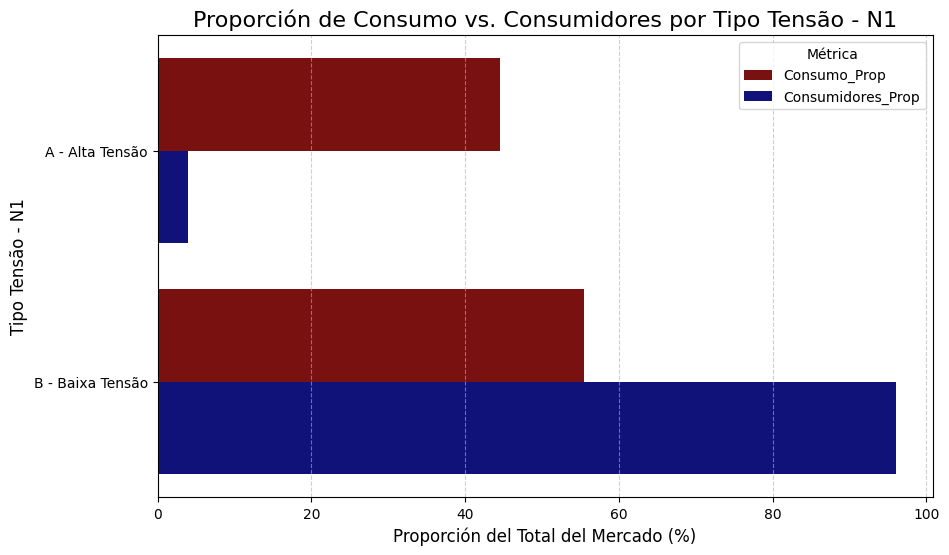

In [29]:
analizador.analizar_proporcion_tension()

### **Interpretacion Grafico Proporcion de Consumo vs. Consumidores por Tipo de Tension**
El grafico de barrar horizontales compara dos metricas porcentuales para cada categoria de tension (Alta y Baja):

+ **Consumo_prop (Rojo Obscuro):** El porcentaje de consumo total de energia generado por ese grupo.

+ **Consumidores_prop (Azul Obscuro):** El porcentaje del numero total de clientes que pertenecen a ese grupo.

**1.Alta Tension (A-Alta Tension)**

+ **Alto Consumo, pocos clientes:** El consumo total(barra roja obscura) es mucho mas largo que la proporcion de clientes (barra azul obscura)

     + **Consumo (Rojo):** Aproximadamente 45% del consumo total del mercado.

     + **Clientes (Azul):** Menos del 5% del total de clientes.

+ **Conclusion:** Esto confirma una **altisima concentracion de demanda**. Un porcentaje muy pequeno de clientes(grandes industrias y empresas, tipicamente conectadas a Alta Tension) es responsable de casi la mitad de toda la energia consumida.

**2.Baja Tension(B-Baja Tension)**

+ **Bajo consumo Individual, Muchos Clientes:** El patron es inverso a Alta Tension.

     + **Clientes(Azul):** representan cerca del 95% del total de consumidores.

     + **Consumo(Rojo):** son responsables de aproximadamente el 55% del consumo total(la parte restante del mercado).

+ **Conclusion:** los clientes de Baja Tension(residenciales y pequenos comercios) son la inmensa mayoria de la base de clientes, pero el consumo individual es bajo, lo que diluye su proporcion en el consumo total.

**3.Conclucion general del grafico.**

El mercado esta segmentado claramente:

+ **Concentracion de Valor(Alta Tension):** Un pequeno grupo de clientes genera un alto porcentaje del ingreso por venta de energia.

+ **Concentracion de Servicio(Baja Tension):** Un gran numero de clientes requiere una vasta infraestructura de servicio al cliente y distribucion.



### **6. Grafico de Ranking de Consumo Promedio(Log) por sector economico.**
Mide la **intensidad de la demanda de energia por cliente** en cada sector.


--- 3. Análisis Sectorial por Consumo Promedio (Log) ---


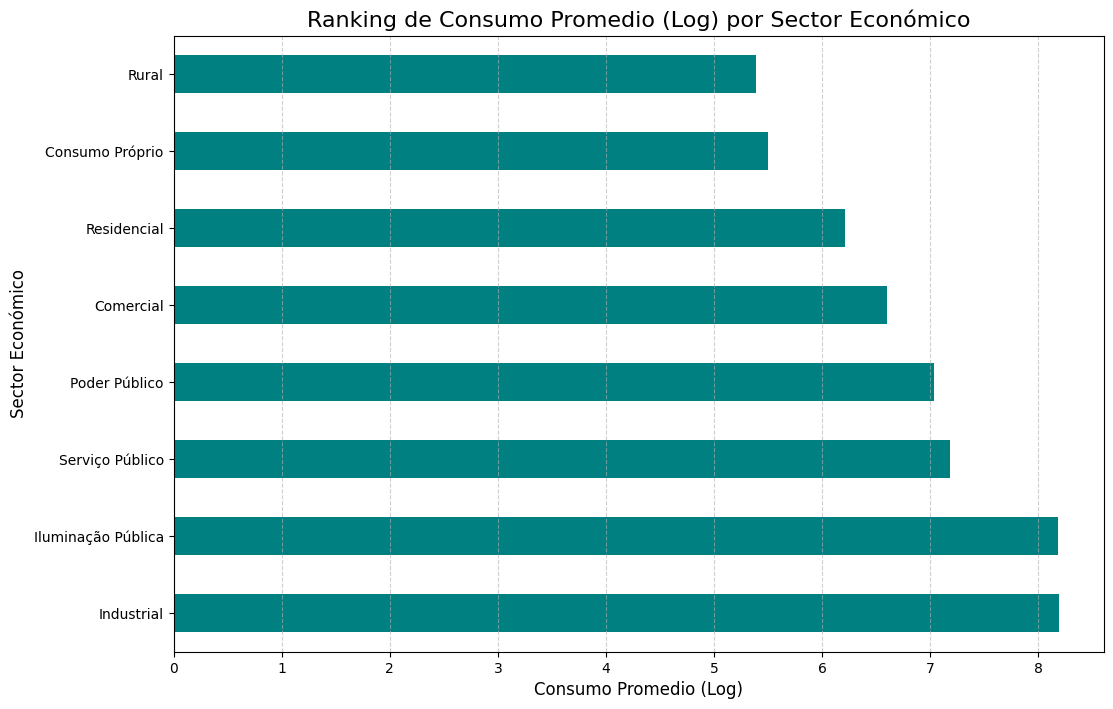

In [30]:
analizador.analizar_sector_consumo()

### **Interpretacion grafico de Grafico Consumo Promedio(Log) por sector Economico**

**1. Mayor Intensidad (Lideres)**

Los sectores industrial e Iluminacion publica tienen los promedios mas altos, superando el valor de 8 en la escala logaritmica.

+ **Significado:** esto implica que cada punto de suministro en estos sectores consume una cantidad de energia.  
     **significativamente mayor** que los clientes de otros sectores.

**2. Alto Promedio.**

Los sectores de **Servicio Publico** y **Poder Publico** tambien muestran promedios muy altos (alrededor de 7) indicando alta demanda por unidad o instalacion.

**3. Bajo Promedio(Alta Densidad)**

Los sectores que tienen mayor cantidad de clientes, como **Residencial** y **Comercial**, se encuentran en la parte media baja del ranking (al rededor de 6.5 en la escala logaritmica).

+ **Contraste:** Su alta contribucion al **consumo total** se debe a la **gran cantidad de clientes**, no a un alto consumo por cliente individual.

**Utilidad**

Este analisis es crucial para la gestion de tarifas y la eficiencia energetica.

**1. Enfoque de Eficiencia:** indica donde se deben prorizar los programas de eficiencia, ya que pequenas mejoras en los sectores de alto consumo promedio (industrial, iluminacion publica) resultaran en el mayor ahorro energetico total.

**2.Rentabilidad de costos:** ayuda a entender la rentabilidad y los costos asociados por tipo de cliente, ya que los clientes de alto promedio suelen requerir menos servicio al cliente individual pero mas capacidad de red.


### **7. Grafico Tendencia del Consumo Industrial por region (UF) y ano.**
Compara el comportamiento del consumo del sector Industrial a lo largo de varios anos en cada estado (UF)


--- Tendencia Anual del Consumo Total de Industrial por Región ---


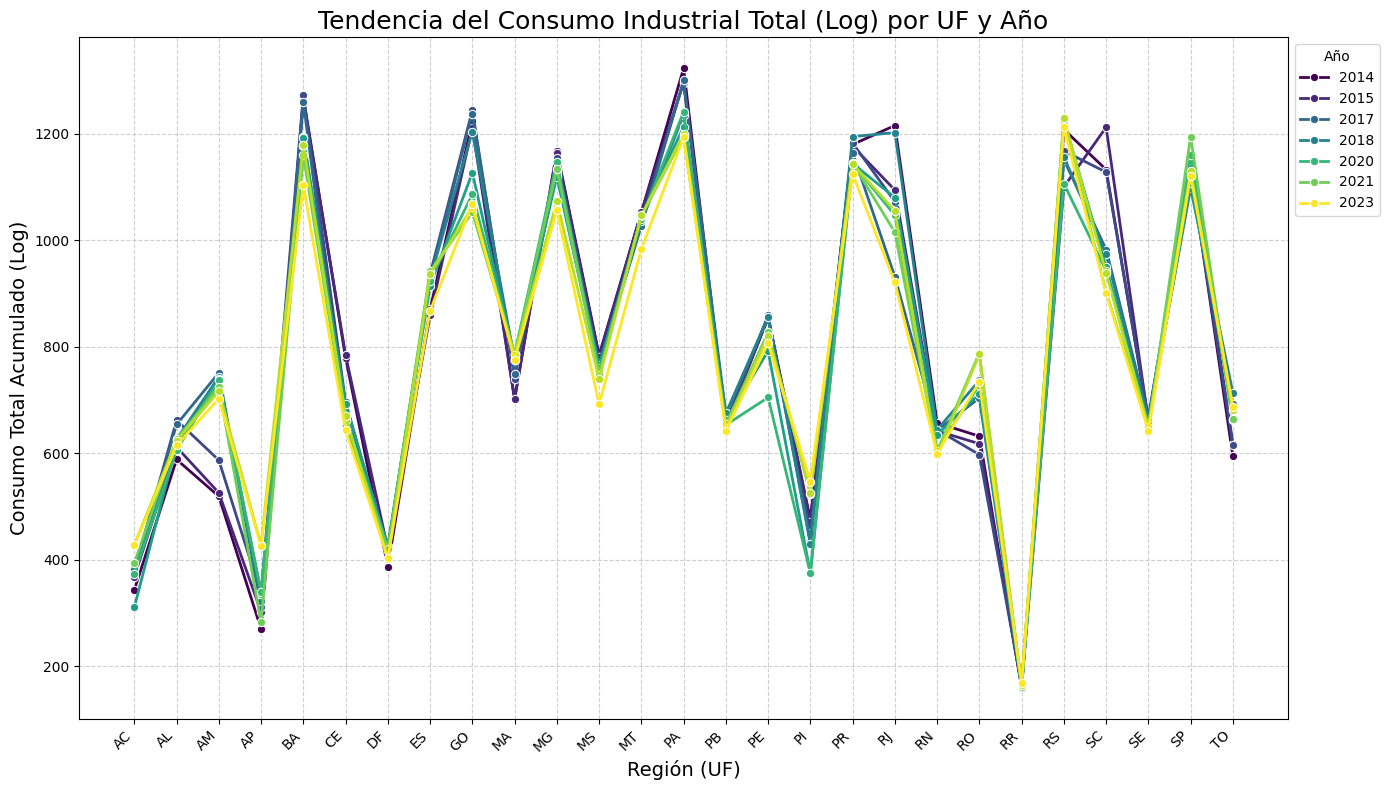

In [31]:
analizador.analizar_tendencia_industrial_regional(setor_n1='Industrial')

### **Interpretacion grafico Tendecia del Consumo Industrial Total por region y Ano.**
**1. Extrema Disparidad Geografica**
+ **Concentracion:** el consumo industrial esta altmente concentrado en unas pocas UFs clave (como BA, PR, SP y RS), que muestran los picos de demandas mas altos (superiores a 1200)
+ **Marginalidad:** otras UFs tienen niveles de consumo industrial mucho mas bajos (cercanos a 400) lo que sugiere poca o nula actividad industrial.

**2. Tendencia volatil:**
+ **Inestabilidad:** El consumo industrial en la mayoria de los estados es volatil, con variaciones significativas de un ano a otro (las lineas se cruzan constantemente). Esto refleja la sensibilidad del sector industrial a los ciclos economicos regionales.

+ **Anos extremos:** 2021 y 2023 suelen estar entre los anos de mayor consumo den la mayoria de las regiones.

### **Utilidad Principal.**
**1.Planificacion de inversiones:** Priorizar las inversiones en la red de transmision y distribucion de las UFs con picos de consumo industrial mas altos, donde la carga es mas pesada y sensible.

**2.Monitoreo economico:** usar el consumo industrial como un indicador rapido de la salud economica y manufacturera de cada estado.


### **8. Grafico de Distribucion de Consumidores por Sector Economico y Tipo de tension.**
Mustra la distribucion de la base de clientes al segmentar simultaneamente por Sector Economico y por Tipo de Tension (Alta vs. Baja)



--- 10. Consumidores por Sector Económico vs. Tipo de Tensión ---


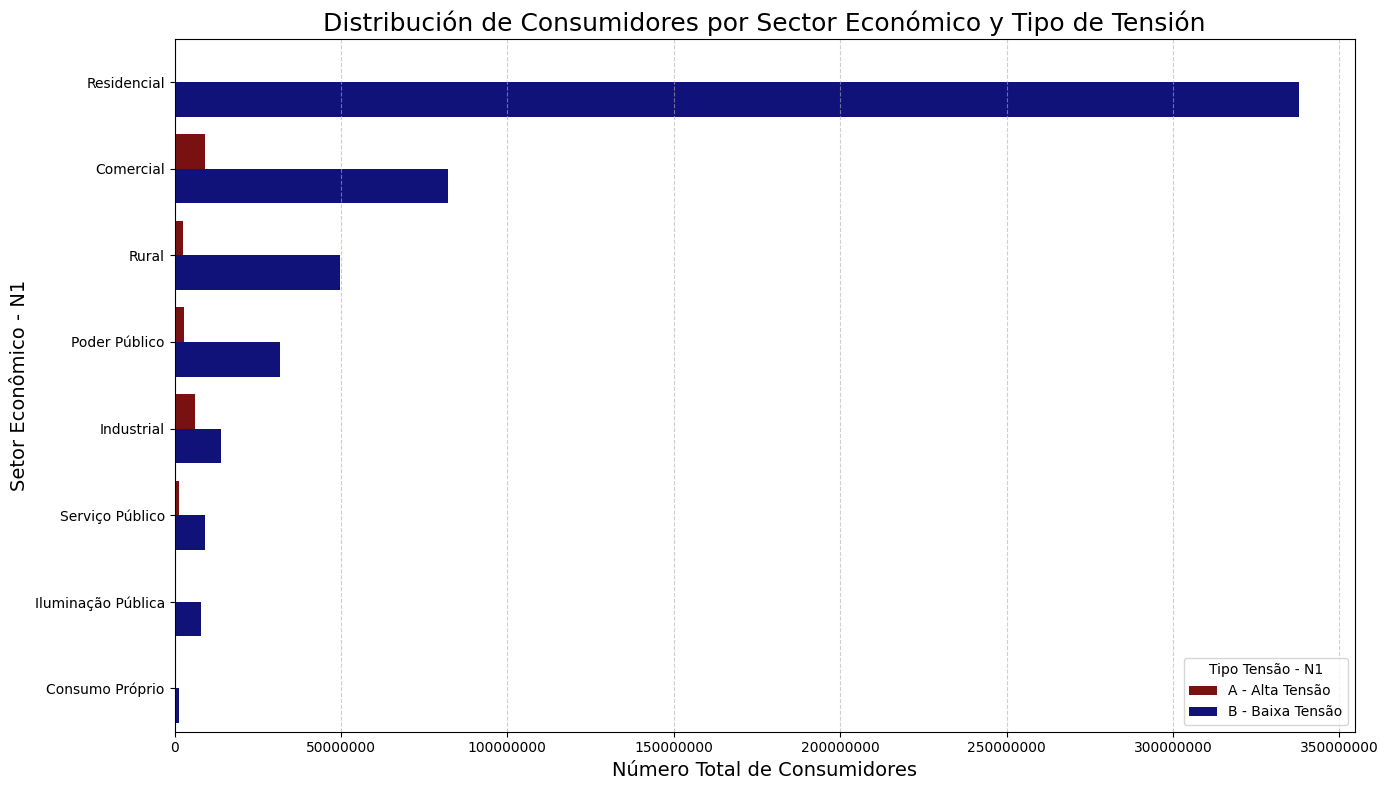

In [32]:
analizador.analizar_tension_por_sector()

### **Interpretacion grafico de Distribucion de Consumidores por Sector Economico y Tipo de Tension.**
El gráfico de barras horizontales está ordenado por el número total de consumidores y utiliza colores para distinguir la contribución de la Alta Tensión (rojo) y la Baja Tensión (azul) en cada sector.

**1. Dominio Absoluto de Baja Tensión**
La característica más evidente es que la Baja Tensión (Barra Azul Oscura) domina casi por completo la base de clientes en la mayoría de los sectores.

+ **Residencial:** El sector con el mayor número de clientes absolutos (cerca de 35,000 millones), y la totalidad de estos clientes están en Baja Tensión.

+ **Comercial y Rural:** Estos sectores también tienen millones de clientes, con la inmensa mayoría conectados a Baja Tensión.

**Contribución de la Alta Tensión (Barra Roja)**
La **Alta Tensión (Barra Roja Oscura)** es prácticamente invisible en comparación con la Baja Tensión, excepto en los siguientes casos:

+ **Comercial:** Es el sector donde la Alta Tensión tiene su mayor base de clientes absoluta fuera del sector Industrial, aunque sigue siendo minúscula en comparación con la Baja Tensión del mismo sector.

+ **Industrial:** Aquí se nota que la Alta Tensión tiene una presencia más significativa en proporción a la Baja Tensión del mismo sector, aunque sigue siendo numéricamente menor. Esto es lógico, ya que la gran industria requiere la potencia de la Alta Tensión.

**3.Conclusion.**
Este análisis cuantifica que la enorme base de clientes del mercado eléctrico se encuentra en el segmento de Baja Tensión, particularmente en los sectores Residencial y Comercial. Los clientes de Alta Tensión son una minoría numérica extrema, incluso en los sectores donde son relevantes (Industrial).

### 9. Grafico de Distribucion Porcentual de Consumidores por Rango de Consumo.

Analiza la segmentacion de la base de clientes segun su calificacion de rango de consumo, lo cual es crucial para programas sociales y tarifas reguladas.


--- 11. Proporción de Consumidores por Rango de Consumo (Faixa de Consumo N1) ---


C:\Users\Alex\AppData\Local\Temp\ipykernel_27296\3723423756.py:400: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


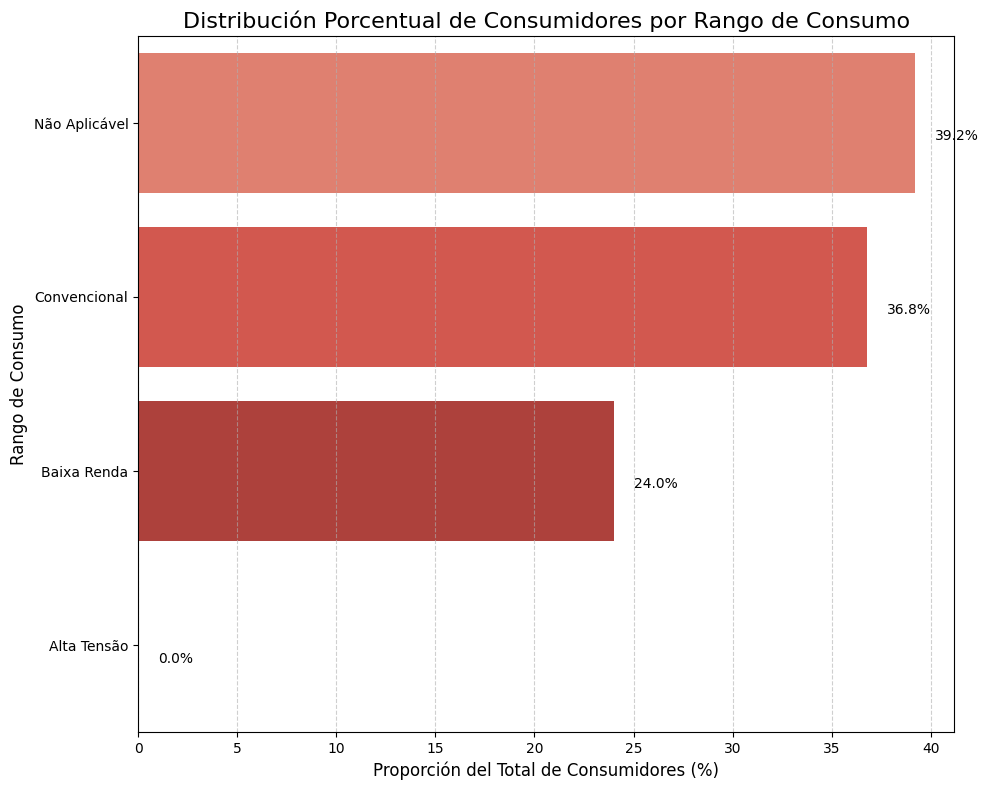

In [33]:
analizador.analizar_segmentacion_clientes(columna_rango='Faixa de Consumo N1')

### Interpretacion del grafico.
El gráfico de barras horizontales muestra el porcentaje de consumidores que caen en diferentes rangos o categorías de consumo/renta.

**1. Dominio de las Categorías Reguladas**
La meyoria de los clientes se concentra en las categorias de Baixa Renda(Baja Renta o Bajos Ingresos) y Convencional, ademas de la categoria Nao Aplicavel (No aplicable) que es el grupo mas grande.

+ **Nao Aplicavel:** es la categoria mas grande con 39.2% de los consumidores, indicando que una porcion significativa de clientes no esta clasificada bajo programas espesificos de renta.

+ **Convencional:** representa el 36.8% de los consumidores.

+ **Baixa Renda:** agrupa el 24.0% de los consumidores. Esto es vital, ya que estos clientes suelen ser elegibles para subsidios o tarifas sociales.

**2.Ausencia de Alta Tensao en Clentes(0.0%)**
+ **Contraste:** esto no significa que no haya clientes de Alta Tensao, sino que no estan incluidos en este analisis de segmentacion por Rango de Consumo. Este tipo de analisis se enfoca generalmente en los clientes de Baja Tension(residenciales/comerciales) que califican para programas sociales o tarifas reguladas.




### **10. Grafico Evolucion Anual del Numero de Consumidores por Rango de Consumo.**
Es un analisis de series de tiempo demograficas que rastrea el crecimiento de la base de clientes de energia, segmentada por categorias de renta y regulacion, desde 2014 hasta 2023.


--- 12. Dinámica de Crecimiento: Evolución de Consumidores por Rango (Faixa de Consumo N1) ---


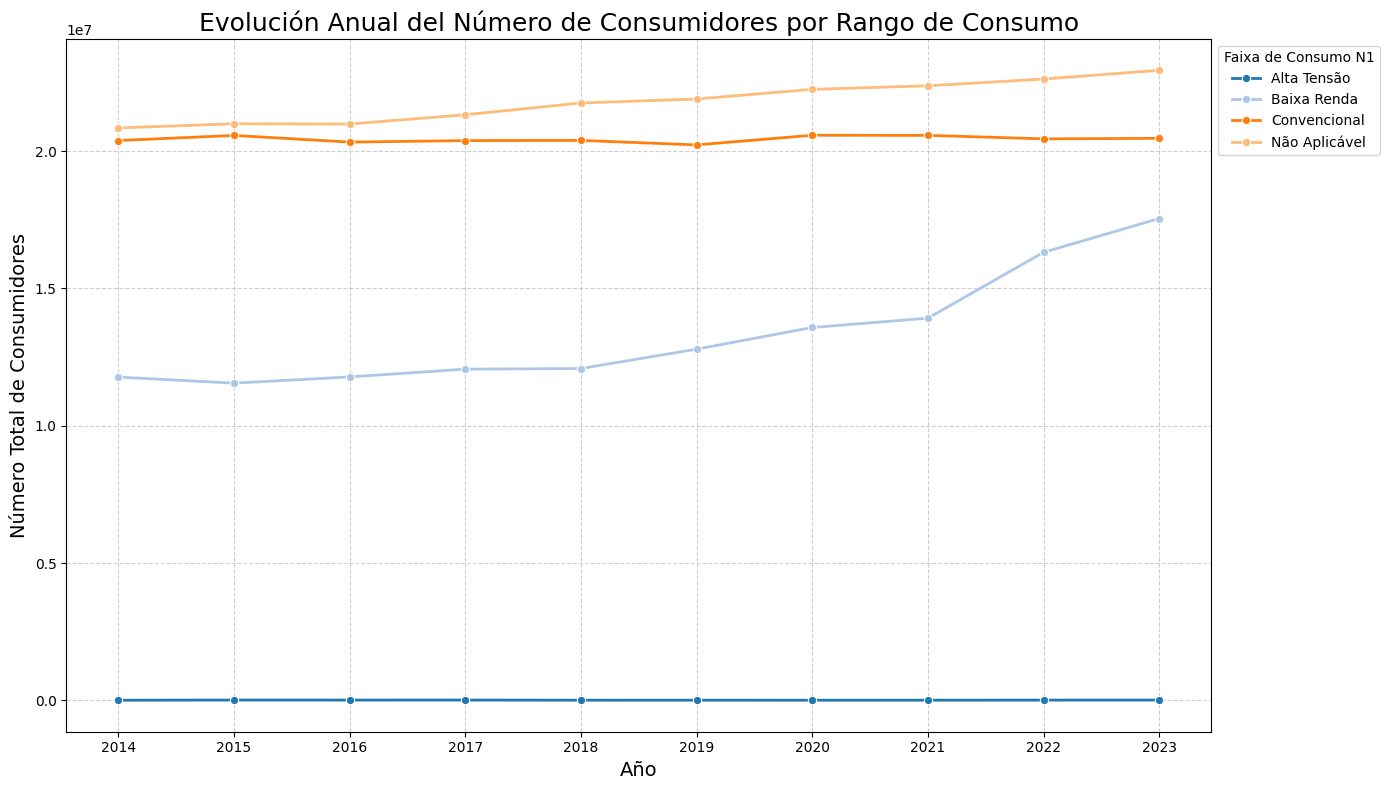

In [34]:
analizador.analizar_dinamica_crecimiento(columna_rango='Faixa de Consumo N1')

### **Interpretacion del grafico Evolucion Anual de Numero de Consumidores por Rango de Consumo**
El grafico de lineas muestra el numero absoluto de consumidores por categoria (eje Y) a lo largo de los años (eje X).

**1. Dominio y Crecimiento de "Bajos Ingresos**

+ **Liderazgo de Crecimiento:** la linea de Baixa Renda(Bajos ingresos)(azul claro) es el que muestra el crecimiento mas pronunciado en el periodo, especialmente a partir de 2021.

     + **Significado:** Esto indica un aumento significativo en el numero de clientes que califican par ala Tarifa Social, ya sea por cambios en los criterios de elegilibilidad o por el crecimiento de la poblacion en esa situacion socio economica.

**2. Crecimiento Estable y Superior (Nao Aplicavel)**

+ La linea **Nao Aplicavel**(naranja claro) representa consistentemente el mayor numero total de consumidores, mostrando un crecimiento lento pero constante a lo largo de toda la decada.

**3. Estancamiento(Concencional y Alta Tensao)** 

+ La categoria **Convencional**(naranja obscuro) se mantiene relativamente plana o muestra un crecimiento marginal.

+ **Alta Tensao**(azul obscuro) permanece en cero, lo que confirma que estos clientes no son contados en el analisis demografico orientado a categorias de Baja Tension.

### CONCLUSION GENERAL

**1. Temporalidad y Crecimiento:** Fuerte Expansión con Estacionalidad Predecible

+ **Tendencia Sostenida:** El mercado ha mostrado un crecimiento robusto y sostenido del consumo total a lo largo de la última década (2014-2024), con una tasa de crecimiento constante (lineal en escala Logarítmica). Esto indica una expansión continua de la demanda en el país.

+ **Estacionalidad:** Existe un patrón de estacionalidad fuerte y predecible, con picos de demanda concentrados consistentemente en los meses más cálidos (típicamente Enero-Marzo), lo que implica una alta dependencia del consumo por aire acondicionado.

**2. Concentración de Valor y Riesgo:** La Regla 80/20
+ Dominio de la **Alta Tensión:** Hay una altísima concentración de demanda en la categoría Alta Tensión (AT). Un porcentaje mínimo de clientes (menos del 5%) es responsable de casi la mitad del consumo total del mercado.

+ **Concentración de Clientes:** Por el contrario, la **Baja Tensión (BT)** abarca la inmensa mayoría de la base de clientes (cerca del 95%), aunque su consumo individual es mucho menor.

+ **Implicación:** El **riesgo de ingresos y la gestión de la carga** están concentrados en un puñado de grandes clientes, mientras que la **gestión operativa y de servicio al cliente** está concentrada en el gran volumen de clientes de BT.

**3. Segmentación: Quién y Dónde**

+ **Dominancia Sectorial (Total):** La mayor parte del consumo total está impulsada por los sectores Residencial y Comercial.

+ **Intensidad (Promedio):** Sin embargo, el Consumo Promedio por cliente (la intensidad) es significativamente más alto en los sectores Industrial e Iluminação Pública (Alumbrado Público). Esto significa que las estrategias de eficiencia deben enfocarse en el sector Industrial para lograr el mayor impacto.

+ **Geografía:** El consumo está fuertemente centralizado en los estados principales como SP y RJ. Además, el consumo del sector Industrial es muy volátil y desigual por región, siendo un indicador clave de la actividad económica local.

**4. Dinámica Demográfica y Social**

+ **Crecimiento Social:** La categoría de clientes de Bajos Ingresos (Baja Renda) es la que ha mostrado el crecimiento más acelerado en el número de consumidores en los últimos años, lo que impacta directamente en el costo proyectado de la Tarifa Social (subsidios).

+ **Preparación de Datos:** La necesidad de usar la transformación logarítmica quedó demostrada por el sesgo extremo de los datos de consumo original, lo cual asegura la robustez de cualquier modelo predictivo futuro.

En resumen, el mercado es un sistema dual: **crece constantemente (Tendencia)**, pero su **valor está concentrado en pocos clientes** (Alta Tensión e Industrial), mientras que sus **recursos operativos** deben atender a una base de clientes socialmente sensible y en constante crecimiento (Baja Tensión y Baja Renda).
